# Out-of-the-Box DeepLabCut Evaluation for XROMM

## Study Goal
Build a reproducible benchmark for out-of-the-box pre-trained DeepLabCut models within the XROMM workflow (X-Ray Of Moving Morphology).

## FAIR Alignment
- **Findable**: each trial receives deterministic split metadata and a global split manifest.
- **Accessible**: all artifacts are written as CSV/JSON in the trial folders.
- **Interoperable**: coordinate schema is preserved from the original `LabeledBodyPartsCoordinates.csv`.
- **Reusable**: split logic is versioned, seed-controlled, and idempotent.

## Input and Output Layout

### Expected Input Per Trial
`{Bird}_{Trial}/CompleteSet/Cam1`, `Cam2`, and `LabeledBodyPartsCoordinates.csv`

### Generated Output Per Trial
- `train/Cam1`, `train/Cam2`, `train/LabeledBodyPartsCoordinates.csv`
- `test/Cam1`, `test/Cam2`, `test/LabeledBodyPartsCoordinates.csv`
- `split_metadata.json` (test/train indices + provenance)

### Global Output
- `Data/split_manifest.csv` summarizing every trial split run

In [2]:
from pathlib import Path
import json
import pandas as pd

from dataset_splitter import split_all_trials
import importlib
import Predictions
import shlex
import subprocess
import sys
import time

import re

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torchvision import transforms

try:
    import umap
except Exception:
    umap = None
import math

import seaborn as sns


importlib.reload(Predictions)

from Predictions import (
    
    evaluate_within_across_blobdetect_all_birds,
    evaluate_within_across_blobdetect_for_bird,

    evaluate_within_across_all_birds,
    evaluate_within_across_for_bird,
)

from training_sets.dataset_builder import build_three_training_sets_for_all_trials

import training_sets.dataset_builder as dsbuilder


## Manifest DF Creation

In [2]:
# Reproducible split settings
DATA_ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials")
TEST_FRAME_COUNT = 300
SEED = 42
OVERWRITE_EXISTING_SPLITS = False

DATA_ROOT

WindowsPath('C:/Users/Salle-Cineradio/Documents/MachineLearning/BirdSongs-MNHN/Testing/DeepLabCutExperiments/CombinedTrials')

In [5]:
manifest_df = split_all_trials(
    data_root=DATA_ROOT,
    test_frame_count=TEST_FRAME_COUNT,
    seed=SEED,
    overwrite=OVERWRITE_EXISTING_SPLITS,
)

manifest_df

,trial_name,trial_path,available_frames,requested_test_frames,selected_test_frames,selected_train_frames,skipped,reason
0,Tulio_T106,C:\Users\Salle-Cineradio\Documents\MachineLear...,3528,300,300,3228,False,
1,Tulio_T56,C:\Users\Salle-Cineradio\Documents\MachineLear...,1908,300,300,1608,False,


In [ ]:
# manifest_df = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\split_manifest.csv").iloc[:, 1:]

In [6]:
# Quick quality checks
summary = {
    "n_trials": int(len(manifest_df)),
    "n_skipped": int(manifest_df["skipped"].sum()) if "skipped" in manifest_df.columns else 0,
    "n_processed": int((~manifest_df["skipped"]).sum()) if "skipped" in manifest_df.columns else int(len(manifest_df)),
}
summary

{'n_trials': 2, 'n_skipped': 0, 'n_processed': 2}

In [7]:
# Inspect one trial metadata file to verify deterministic indices are stored
trial_dirs = sorted([p for p in DATA_ROOT.iterdir() if p.is_dir()])
sample_trial = trial_dirs[0] if trial_dirs else None
if sample_trial is None:
    raise RuntimeError("No trial folders found under DATA_ROOT")

metadata_path = sample_trial / "split_metadata.json"
metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
metadata

{'version': 1,
 'created_unix': 1784643510,
 'trial_name': 'Tulio_T106',
 'trial_path': 'C:\\Users\\Salle-Cineradio\\Documents\\MachineLearning\\BirdSongs-MNHN\\Testing\\DeepLabCutExperiments\\CombinedTrials\\Tulio_T106',
 'seed': 42,
 'test_frame_count_requested': 300,
 'available_frames_used': 3528,
 'cam1_image_count': 3528,
 'cam2_image_count': 3528,
 'csv_row_count': 3528,
 'test_indices': [2,
  13,
  26,
  29,
  47,
  79,
  86,
  102,
  108,
  122,
  128,
  130,
  131,
  177,
  187,
  192,
  221,
  229,
  237,
  241,
  260,
  262,
  271,
  276,
  283,
  284,
  290,
  292,
  322,
  326,
  350,
  356,
  372,
  379,
  383,
  386,
  396,
  397,
  413,
  418,
  419,
  435,
  449,
  456,
  458,
  469,
  495,
  511,
  515,
  525,
  541,
  566,
  571,
  585,
  626,
  636,
  647,
  653,
  655,
  661,
  666,
  669,
  676,
  700,
  731,
  779,
  787,
  814,
  823,
  858,
  864,
  867,
  870,
  877,
  881,
  895,
  898,
  899,
  902,
  914,
  920,
  933,
  937,
  938,
  942,
  952,
  953,
  

## Build Three Training Sets Per Trial (Dataset Creation Only)

From each trial's `train/` split, create model-input subsets:

- `random_train`
- `displacement_train` (zone size 150)
- `dino_train`

This stage mirrors `train_update_model` setup through dataset creation and **stops before model training** (`dlcs.create_and_train`).

In [3]:

TRAINING_NFRAMES = (100, 50)
TRAINING_EPOCHS = 125
TRAINING_SEED = 42
DISPLACEMENT_ZONE_SIZE = 150

TRAINING_NFRAMES, TRAINING_EPOCHS, TRAINING_SEED, DISPLACEMENT_ZONE_SIZE

((100, 50), 125, 42, 150)

In [9]:
training_manifest_df = build_three_training_sets_for_all_trials(
    data_root=DATA_ROOT,
    nframes_values=TRAINING_NFRAMES,
    epochs=TRAINING_EPOCHS,
    frame_selection_seed=TRAINING_SEED,
    zone_size=DISPLACEMENT_ZONE_SIZE,
)

training_manifest_df

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T106\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-21\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T106\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-21\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T106\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-21\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T106\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-21\dlc-models"
Attempting to create a symbolic link of the

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T106\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-21\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T106\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-21\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T106\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-21\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T106\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-21\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Docume

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T56\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-21\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T56\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-21\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T56\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-21\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T56\random_train\nframes_100\ModelsToTune\Canari-FineTuner-2026-07-21\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Docume

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T56\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-21\videos"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T56\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-21\labeled-data"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T56\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-21\training-datasets"
Created "C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\Tulio_T56\random_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-21\dlc-models"
Attempting to create a symbolic link of the video ...
Symlink creation impossible (exFat architecture?): copying the video instead.
C:\Users\Salle-Cineradio\Documents\

,trial_folder,bird,trial_num,method,nframes,epochs,output_root,config_path,selection_count,status,message
0,Tulio_T106,Tulio,106,random,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
1,Tulio_T106,Tulio,106,displacement,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
2,Tulio_T106,Tulio,106,dino,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
3,Tulio_T106,Tulio,106,random,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created
4,Tulio_T106,Tulio,106,displacement,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created
5,Tulio_T106,Tulio,106,dino,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created
6,Tulio_T56,Tulio,56,random,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
7,Tulio_T56,Tulio,56,displacement,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
8,Tulio_T56,Tulio,56,dino,100,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,100,ok,Combined DLC dataset created
9,Tulio_T56,Tulio,56,random,50,125,C:\Users\Salle-Cineradio\Documents\MachineLear...,C:\Users\Salle-Cineradio\Documents\MachineLear...,50,ok,Combined DLC dataset created


## Provenance Notes

- Splits are deterministic from `SEED=42`.
- If Cam1/Cam2/CSV lengths differ, the split uses the aligned minimum count to maintain row-image correspondence.
- This notebook is designed for repeated reruns as new trial folders are added to `Data/`.

## Next Benchmark Steps

1. Train/evaluate out-of-the-box pretrained DeepLabCut models on each split.
2. Compute per-trial and pooled error metrics against held-out `test` labels.
3. Export a model-comparison table and publication figures with confidence intervals.
4. Record software/version metadata for full reproducibility in manuscript supplements.

## Embedding Comparison of Split Usage

This reproduces the Cell 67-style embedding scatter view for one trial:

- all images in dark background points
- bright overlays for selected frames from `random_train`, `displacement_train`, `dino_train`
- bright overlay for held-out `test` frames

## ------------------------------------------------------------

In [12]:


TRIAL_FOR_EMBED_VIS = "Hans_T1"  # Example: DB_T15, DB_T16, DB_T17, Tulio_T10, Tulio_T5
NFRAMES_FOR_METHOD_METADATA = 50  # pick 100 or 50
CAMERA_FOR_EMBED_VIS = "Cam1"

DINO_BATCH_SIZE = 32
DINO_MODEL_NAME = "dinov2_vits14"
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "cosine"
RANDOM_SEED = 42


In [10]:


def _image_sort_key(path: Path) -> tuple[int, str]:
    match = re.search(r"(\d+)(?!.*\d)", path.stem)
    idx = int(match.group(1)) if match else -1
    return idx, path.name.lower()


def _list_images_sorted(folder: Path) -> list[Path]:
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    return sorted([p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in exts], key=_image_sort_key)


def _read_selected_indices(trial_dir: Path, method_name: str, nframes: int) -> list[int]:
    metadata_path = trial_dir / f"{method_name}_train" / f"nframes_{int(nframes)}" / "dataset_build_metadata.json"
    if not metadata_path.exists():
        return []
    data = json.loads(metadata_path.read_text(encoding="utf-8"))
    return [int(x) for x in data.get("selected_indices", [])]


def _load_split_test_filenames(trial_dir: Path, camera: str = "Cam1") -> set[str]:
    test_dir = trial_dir / "test" / camera
    return {p.name for p in _list_images_sorted(test_dir)}


def _compute_dino_embeddings(image_paths: list[Path], batch_size: int = 32, model_name: str = "dinov2_vits14") -> np.ndarray:
    if not image_paths:
        raise ValueError("No images found for embedding computation")

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(device)

    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )

    all_feats = []
    for start in range(0, len(image_paths), int(batch_size)):
        batch_paths = image_paths[start : start + int(batch_size)]
        batch_tensors = []
        for image_path in batch_paths:
            with Image.open(image_path) as image_file:
                batch_tensors.append(transform(image_file.convert("RGB")))
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            feats = model(batch)
        all_feats.append(feats.detach().cpu())

    embeddings = torch.cat(all_feats, dim=0)
    embeddings = embeddings / embeddings.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return embeddings.numpy()



In [13]:

DATA_ROOT = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data")
TRIAL_DIR = DATA_ROOT / TRIAL_FOR_EMBED_VIS

if not TRIAL_DIR.exists():
    raise FileNotFoundError(f"Trial folder not found: {TRIAL_DIR}")

COMPLETE_CAM_DIR = TRIAL_DIR / "CompleteSet" / CAMERA_FOR_EMBED_VIS
TRAIN_CAM_DIR = TRIAL_DIR / "train" / CAMERA_FOR_EMBED_VIS

complete_images = _list_images_sorted(COMPLETE_CAM_DIR)
train_images = _list_images_sorted(TRAIN_CAM_DIR)

if not complete_images:
    raise RuntimeError(f"No complete-set images found in: {COMPLETE_CAM_DIR}")
if not train_images:
    raise RuntimeError(f"No train-set images found in: {TRAIN_CAM_DIR}")

# Compute DINO embeddings for all complete-set images (background cloud)
embeddings = _compute_dino_embeddings(
    complete_images,
    batch_size=DINO_BATCH_SIZE,
    model_name=DINO_MODEL_NAME,
)

if umap is not None:
    reducer = umap.UMAP(
        n_neighbors=UMAP_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        metric=UMAP_METRIC,
        random_state=RANDOM_SEED,
    )
    embedding_2d = reducer.fit_transform(embeddings)
else:
    from sklearn.decomposition import PCA

    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    embedding_2d = pca.fit_transform(embeddings)

# Build index sets for overlays by mapping selected train image names into complete-set positions.
complete_name_to_idx = {p.name: i for i, p in enumerate(complete_images)}
train_name_list = [p.name for p in train_images]

method_to_indices = {}
for method in ("random", "displacement", "dino"):
    train_local_indices = _read_selected_indices(TRIAL_DIR, method, NFRAMES_FOR_METHOD_METADATA)
    selected_names = [train_name_list[i] for i in train_local_indices if 0 <= i < len(train_name_list)]
    method_to_indices[method] = np.asarray([complete_name_to_idx[name] for name in selected_names if name in complete_name_to_idx], dtype=int)

test_names = _load_split_test_filenames(TRIAL_DIR, CAMERA_FOR_EMBED_VIS)
test_indices = np.asarray([complete_name_to_idx[name] for name in test_names if name in complete_name_to_idx], dtype=int)

print(
    {
        "trial": TRIAL_FOR_EMBED_VIS,
        "camera": CAMERA_FOR_EMBED_VIS,
        "n_all_images": len(complete_images),
        "n_random": int(method_to_indices["random"].size),
        "n_displacement": int(method_to_indices["displacement"].size),
        "n_dino": int(method_to_indices["dino"].size),
        "n_test": int(test_indices.size),
        "reducer": "UMAP" if umap is not None else "PCA (fallback)",
    }
)

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


{'trial': 'Hans_T1', 'camera': 'Cam1', 'n_all_images': 1115, 'n_random': 50, 'n_displacement': 50, 'n_dino': 50, 'n_test': 300, 'reducer': 'UMAP'}


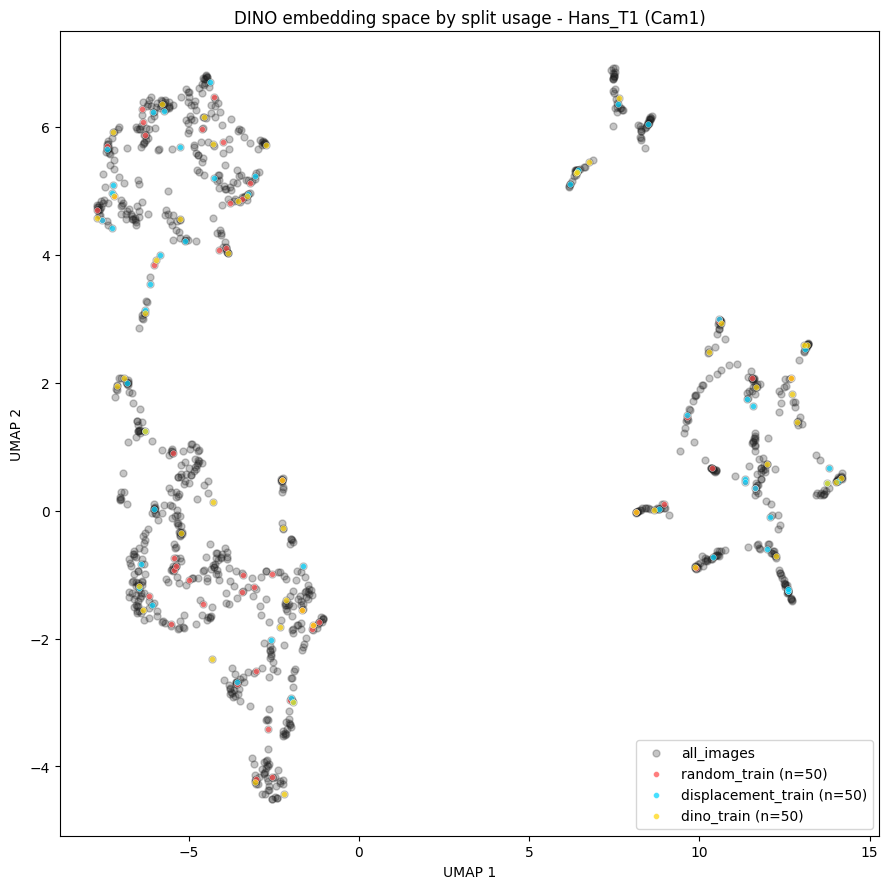

In [14]:
# Cell-67-style scatter overlay: dark background cloud + bright split selections
plt.figure(figsize=(9, 9))

# All images (background)
plt.scatter(
    embedding_2d[:, 0],
    embedding_2d[:, 1],
    s=25,
    alpha=0.25,
    c="#1b1b1b",
    label="all_images",
)

overlay_specs = [
    ("random", "#ff4d4d"),
    ("displacement", "#00d4ff"),
    ("dino", "#ffd60a"),
]

for method_name, color in overlay_specs:
    idx = method_to_indices.get(method_name, np.asarray([], dtype=int))
    if idx.size == 0:
        continue
    plt.scatter(
        embedding_2d[idx, 0],
        embedding_2d[idx, 1],
        s=18,
        alpha=0.72,
        c=color,
        edgecolors="white",
        linewidths=0.35,
        label=f"{method_name}_train (n={idx.size})",
    )

# if test_indices.size > 0:
#     plt.scatter(
#         embedding_2d[test_indices, 0],
#         embedding_2d[test_indices, 1],
#         s=25,
#         alpha=0.95,
#         c="#39ff14",
#         marker="^",
#         edgecolors="black",
#         linewidths=0.45,
#         label=f"test_split (n={test_indices.size})",
#     )

plt.legend(loc="best", frameon=True)
plt.title(f"DINO embedding space by split usage - {TRIAL_FOR_EMBED_VIS} ({CAMERA_FOR_EMBED_VIS})")
plt.xlabel("UMAP 1" if umap is not None else "PC 1")
plt.ylabel("UMAP 2" if umap is not None else "PC 2")
plt.tight_layout()
plt.show()

### All-Trials Split Embedding Grid

Run this to generate the same split-overlay visualization for every trial in `Data/`.

In [ ]:
from sklearn.svm import SVC


In [24]:



def _build_dino_model_once(model_name: str = "dinov2_vits14"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = torch.hub.load("facebookresearch/dinov2", model_name)
    model.eval().to(device)
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )
    return model, transform, device


def _compute_embeddings_with_model(image_paths, model, transform, device, batch_size: int = 32):
    feats = []
    for start in range(0, len(image_paths), int(batch_size)):
        batch_paths = image_paths[start : start + int(batch_size)]
        batch_tensors = []
        for image_path in batch_paths:
            with Image.open(image_path) as image_file:
                batch_tensors.append(transform(image_file.convert("RGB")))
        batch = torch.stack(batch_tensors).to(device)
        with torch.no_grad():
            out = model(batch)
        feats.append(out.detach().cpu())

    emb = torch.cat(feats, dim=0)
    emb = emb / emb.norm(dim=1, keepdim=True).clamp_min(1e-12)
    return emb.numpy()


In [ ]:
# Embeddings for one camera
def plot_all_trials_split_embeddings(
    data_root: Path,
    nframes: int = 50,
    camera: str = "Cam1",
    batch_size: int = 32,
):
    trial_dirs = sorted(
        [
            p
            for p in data_root.iterdir()
            if p.is_dir() and (p / "CompleteSet" / camera).exists()
        ]
    )

    if len(trial_dirs) == 0:
        raise RuntimeError(f"No trials found under {data_root} for camera {camera}")

    model, transform, device = _build_dino_model_once(
        model_name=DINO_MODEL_NAME
    )

    all_embeddings = []
    method_indices = {"random": [], "displacement": [], "dino": []}

    start = 0

    for trial_dir in trial_dirs:
        complete_images = _list_images_sorted(trial_dir / "CompleteSet" / camera)
        train_images = _list_images_sorted(trial_dir / "train" / camera)

        if len(complete_images) == 0 or len(train_images) == 0:
            continue

        embeddings = _compute_embeddings_with_model(
            complete_images,
            model=model,
            transform=transform,
            device=device,
            batch_size=batch_size,
        )

        all_embeddings.append(embeddings)

        complete_name_to_idx = {p.name: i for i, p in enumerate(complete_images)}
        train_name_list = [p.name for p in train_images]

        for method in ("random", "displacement", "dino"):
            train_local_indices = _read_selected_indices(
                trial_dir, method, int(nframes)
            )

            selected_names = [
                train_name_list[i]
                for i in train_local_indices
                if 0 <= i < len(train_name_list)
            ]

            global_idx = np.asarray(
                [
                    complete_name_to_idx[name] + start
                    for name in selected_names
                    if name in complete_name_to_idx
                ],
                dtype=int,
            )

            method_indices[method].append(global_idx)

        start += len(embeddings)

    all_embeddings = np.vstack(all_embeddings)

    if umap is not None:
        reducer = umap.UMAP(
            n_neighbors=UMAP_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_SEED,
        )
        embedding_2d = reducer.fit_transform(all_embeddings)
        xlab, ylab = "UMAP 1", "UMAP 2"
    else:
        from sklearn.decomposition import PCA

        pca = PCA(n_components=2, random_state=RANDOM_SEED)
        embedding_2d = pca.fit_transform(all_embeddings)
        xlab, ylab = "PC 1", "PC 2"

    fig, ax = plt.subplots(figsize=(10, 8))

    # Background: every image
    ax.scatter(
        embedding_2d[:, 0],
        embedding_2d[:, 1],
        s=20,
        alpha=0.22,
        c="#1b1b1b",
        label="all_images",
    )

    colors = {
        "random": "#ff4d4d",
        "displacement": "#00d4ff",
        "dino": "#ffd60a",
    }
    i = 1
    for method, color in colors.items():
        if len(method_indices[method]) == 0:
            continue
        alpha = .9/i

        idx = np.concatenate(method_indices[method])

        ax.scatter(
            embedding_2d[idx, 0],
            embedding_2d[idx, 1],
            s=20,
            alpha=alpha,
            c=color,
            # edgecolors="white",
            # linewidths=0.3,
            label=f"{method}",
        )
        i = i + .5

    ax.set_title(
        f"All Trials - Split Usage Embeddings (nframes={nframes}, camera={camera})"
    )
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_all_trials_split_embeddings(
    data_root=DATA_ROOT,
    nframes=NFRAMES_FOR_METHOD_METADATA,
    camera="Cam1",
    batch_size=DINO_BATCH_SIZE,
    
)

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


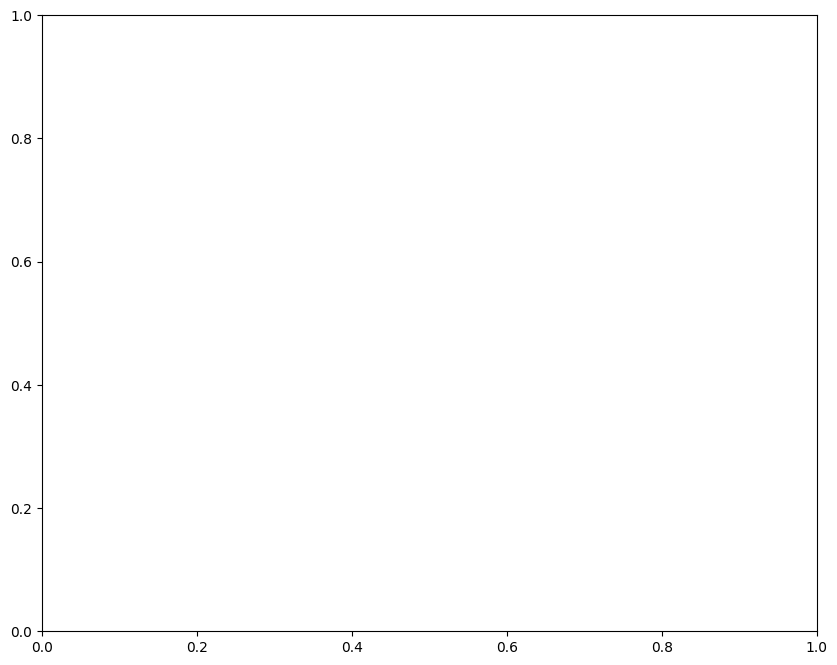

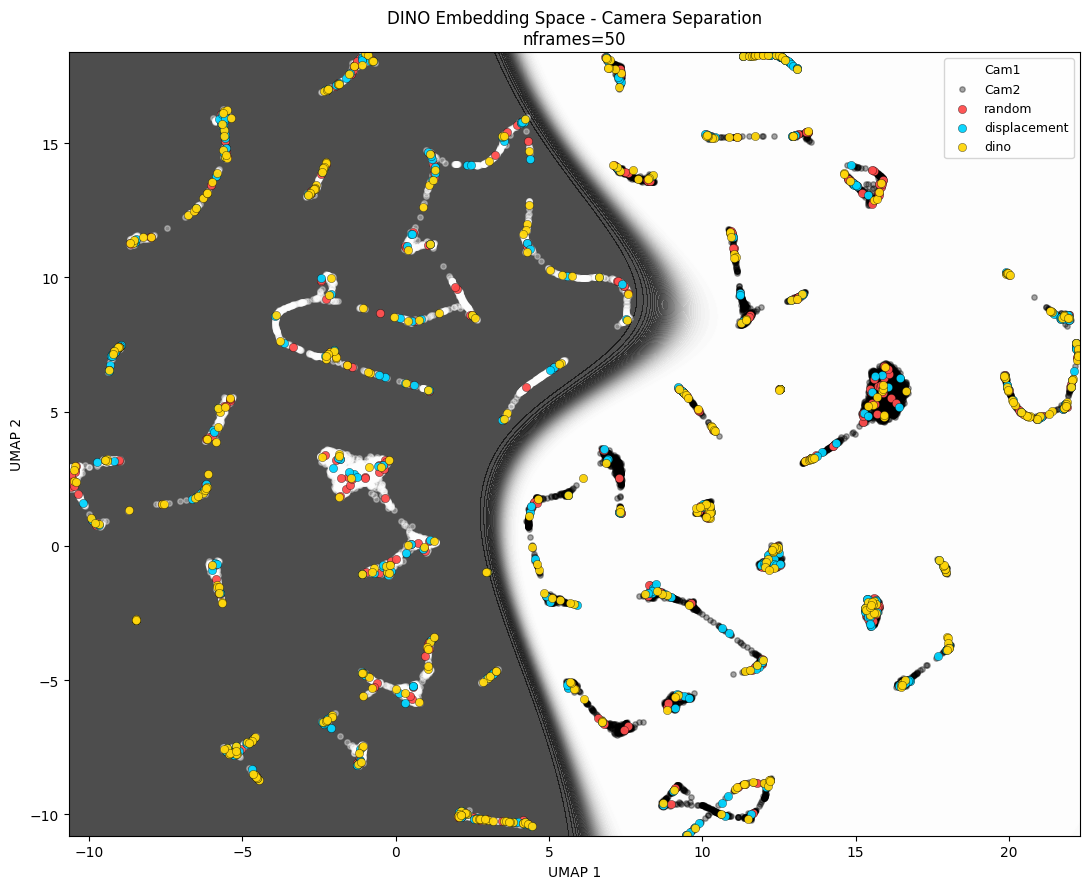

<Figure size 640x480 with 0 Axes>

In [ ]:
# Embeddings for both cameras with backdrop
def plot_all_trials_split_embeddings(
    data_root: Path,
    nframes: int = 50,
    cameras=("Cam1", "Cam2"),
    batch_size: int = 32,
):
    trial_dirs = sorted([p for p in data_root.iterdir() if p.is_dir()])

    model, transform, device = _build_dino_model_once(
        model_name=DINO_MODEL_NAME
    )

    all_embeddings = []
    all_cameras = []
    method_indices = {"random": [], "displacement": [], "dino": []}

    start = 0

    for trial_dir in trial_dirs:
        if "evaluation_results" in str(trial_dir):
            continue
        for camera in cameras:

            complete_images = _list_images_sorted(
                trial_dir / "CompleteSet" / camera
            )
            train_images = _list_images_sorted(
                trial_dir / "train" / camera
            )

            if len(complete_images) == 0 or len(train_images) == 0:
                continue

            embeddings = _compute_embeddings_with_model(
                complete_images,
                model=model,
                transform=transform,
                device=device,
                batch_size=batch_size,
            )

            all_embeddings.append(embeddings)
            all_cameras.extend([camera] * len(embeddings))

            complete_name_to_idx = {
                p.name: i for i, p in enumerate(complete_images)
            }
            train_name_list = [p.name for p in train_images]

            for method in method_indices.keys():

                train_local_indices = _read_selected_indices(
                    trial_dir, method, int(nframes)
                )

                selected_names = [
                    train_name_list[i]
                    for i in train_local_indices
                    if 0 <= i < len(train_name_list)
                ]

                global_idx = np.asarray(
                    [
                        complete_name_to_idx[name] + start
                        for name in selected_names
                        if name in complete_name_to_idx
                    ],
                    dtype=int,
                )

                method_indices[method].append(global_idx)

            start += len(embeddings)

    all_embeddings = np.vstack(all_embeddings)
    all_cameras = np.asarray(all_cameras)


    # dimensionality reduction
    if umap is not None:
        reducer = umap.UMAP(
            n_neighbors=UMAP_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_SEED,
        )
        embedding_2d = reducer.fit_transform(all_embeddings)
        xlab, ylab = "UMAP 1", "UMAP 2"

    else:
        from sklearn.decomposition import PCA

        embedding_2d = PCA(
            n_components=2,
            random_state=RANDOM_SEED
        ).fit_transform(all_embeddings)

        xlab, ylab = "PC 1", "PC 2"


    fig, ax = plt.subplots(figsize=(10, 8))


    # Plot cameras separately
    camera_styles = {
        "Cam1": ("#377eb8", "o"),
        "Cam2": ("#e41a1c", "^"),
    }

    for cam, (color, marker) in camera_styles.items():

        idx = np.where(all_cameras == cam)[0]
        
    # ============================
    # Camera separation classifier
    # ============================

    y_cam = (all_cameras == "Cam2").astype(int)

    # cam_clf = SVC(
    #     kernel="linear",
    #     probability=True
    # )
    cam_clf = SVC(
        kernel="rbf",
        gamma="scale",
        C=5,
        probability=True
    )
    cam_clf.fit(
        embedding_2d,
        y_cam
    )


    fig, ax = plt.subplots(
        figsize=(11, 9),
        facecolor="white"
    )


    # ============================
    # Draw camera background
    # ============================

    x_min, x_max = embedding_2d[:,0].min(), embedding_2d[:,0].max()
    y_min, y_max = embedding_2d[:,1].min(), embedding_2d[:,1].max()

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    cam_probability = cam_clf.predict_proba(grid)[:, 1]
    cam_probability = cam_probability.reshape(xx.shape)

    ax.contourf(
        xx,
        yy,
        cam_probability,
        levels=np.linspace(0,1,50),
        cmap="gray",
        alpha=0.7
    )


    # ============================
    # Plot camera points
    # ============================

    cam1_idx = np.where(all_cameras == "Cam1")[0]
    cam2_idx = np.where(all_cameras == "Cam2")[0]


    ax.scatter(
        embedding_2d[cam1_idx,0],
        embedding_2d[cam1_idx,1],
        s=15,
        c="white",
        alpha=0.35,
        label="Cam1"
    )


    ax.scatter(
        embedding_2d[cam2_idx,0],
        embedding_2d[cam2_idx,1],
        s=15,
        c="black",
        edgecolors="black",
        alpha=0.35,
        label="Cam2"
    )


    # ============================
    # Overlay selected frames
    # ============================

    method_colors = {
        "random": "#ff4d4d",
        "displacement": "#00d4ff",
        "dino": "#ffd60a",
    }


    for method, color in method_colors.items():

        if len(method_indices[method]) == 0:
            continue

        idx = np.concatenate(method_indices[method])

        ax.scatter(
            embedding_2d[idx,0],
            embedding_2d[idx,1],
            s=35,
            c=color,
            edgecolors="black",
            linewidths=0.25,
            alpha=0.95,
            label=method
        )


    ax.set_title(
        f"DINO Embedding Space - Camera Separation\nnframes={nframes}"
    )

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)

    ax.legend(
        frameon=True,
        fontsize=9
    )

    plt.tight_layout()
    plt.show()

    ax.set_title(
        f"All Trials - Both Cameras - DINO embeddings (nframes={nframes})"
    )
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_all_trials_split_embeddings(
    data_root=DATA_ROOT,
    nframes=NFRAMES_FOR_METHOD_METADATA,
    cameras=("Cam1", "Cam2"),

    batch_size=DINO_BATCH_SIZE,
    # ncols=3,
)

# ------------------------------------------------------------

### Full Suite Training (Single GPU, Trial-Agnostic Timing)

Run the next cell to train the entire generated suite (`random`, `displacement`, `dino` × `nframes` 100/50) on a single GPU.

This writes a run-level manifest with per-job timing (`elapsed_seconds`), which we summarize in the following analysis cell.

In [ ]:

# Resolve paths robustly whether notebook is opened at repo root or DeepLabCutExperiments/
def _resolve_training_paths_training() -> tuple[Path, Path]:
    cwd = Path.cwd().resolve()

    direct_script = cwd / "training_sets" / "train_all_models.py"
    direct_manifest = cwd / "CombinedTrials" / "training_set_build_manifest.csv"
    if direct_script.exists() and direct_manifest.exists():
        return direct_script, direct_manifest

    nested_script = cwd / "DeepLabCutExperiments" / "training_sets" / "train_all_models.py"
    nested_manifest = cwd / "DeepLabCutExperiments" / "CombinedTrials" / "training_set_build_manifest.csv"
    if nested_script.exists() and nested_manifest.exists():
        return nested_script, nested_manifest

    raise FileNotFoundError(
        "Could not resolve training script/manifest. Expected either "
        "training_sets/train_all_models.py + CombinedTrials/training_set_build_manifest.csv "
        "or DeepLabCutExperiments/training_sets/train_all_models.py + "
        "DeepLabCutExperiments/CombinedTrials/training_set_build_manifest.csv from current working directory."
    )


In [ ]:

TRAIN_SCRIPT, TRAINING_SET_BUILD_MANIFEST = _resolve_training_paths_training()
TRAINING_DATA_DIR = TRAINING_SET_BUILD_MANIFEST.parent

# Single-GPU full-suite defaults
EPOCHS = 125
METHODS = ["random", "displacement", "dino"]
NFRAMES = [100, 50]
MAX_WORKERS = 1  # single GPU

# Keep conservative defaults for single GPU stability; tune upward later if VRAM allows.
TRAIN_NETWORK_KWARGS = {
    "batch_size": 16,

}

cmd = [
    sys.executable,
    "-u",  # unbuffered output so notebook shows progress lines live
    str(TRAIN_SCRIPT),
    "--manifest",
    str(TRAINING_SET_BUILD_MANIFEST),
    "--epochs",
    str(EPOCHS),
    "--methods",
    *METHODS,
    "--nframes",
    *[str(v) for v in NFRAMES],
    "--max-workers",
    str(MAX_WORKERS),
    "--train-network-kwargs-json",
    json.dumps(TRAIN_NETWORK_KWARGS),
]

print("Launching training command:")
print(" ".join(shlex.quote(x) for x in cmd))
print("\nExpected progress format:")
print("- [train-job i/N] Bird_Ttrial | nframes=... | method=...")
print("- [epoch-progress] ... [#####-----] epoch/total")
print("- [suite-progress] completed=.../N ok=... error=...")

wall_t0 = time.perf_counter()
# proc = subprocess.run(cmd, check=False)
proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

for line in proc.stdout:
    print(line, end="")

returncode = proc.wait()
wall_elapsed = time.perf_counter() - wall_t0

print(f"\nTraining process return code: {proc.returncode}")
print(f"Wall-clock elapsed: {wall_elapsed/3600:.2f} hours")

run_manifests = sorted(
    TRAINING_DATA_DIR.glob("training_run_manifest_*.csv"),
    key=lambda p: p.stat().st_mtime,
)
LATEST_TRAINING_RUN_MANIFEST = run_manifests[-1] if run_manifests else None
print("Latest run manifest:", LATEST_TRAINING_RUN_MANIFEST)

Launching training command:
'c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\python.exe' -u 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\training_sets\train_all_models.py' --manifest 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\training_set_build_manifest.csv' --epochs 125 --methods random displacement dino --nframes 100 50 --max-workers 1 --train-network-kwargs-json '{"batch_size": 16}'

Expected progress format:
- [train-job i/N] Bird_Ttrial | nframes=... | method=...
- [epoch-progress] ... [#####-----] epoch/total
- [suite-progress] completed=.../N ok=... error=...
Loaded 12 training jobs
Applying bird bodypart sync to all target configs before training...
Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
 bird                                                                               

In [9]:
# Full-suite runner scoped to one trial: DB_T16


TRAIN_SCRIPT, TRAINING_SET_BUILD_MANIFEST = _resolve_training_paths()
TRAINING_DATA_DIR = TRAINING_SET_BUILD_MANIFEST.parent

# Target only one trial
TARGET_BIRD = "DavidBowie"   # DB
TARGET_TRIAL_NUM = 16
EPOCHS = 125
METHODS = ["random", "displacement", "dino"]
NFRAMES = [100, 50]
MAX_WORKERS = 1

TRAIN_NETWORK_KWARGS = {
    "batch_size": 12,
}

manifest_df = pd.read_csv(TRAINING_SET_BUILD_MANIFEST)
required_cols = {"bird", "trial_num"}
missing = required_cols - set(manifest_df.columns)
if missing:
    raise ValueError(f"Manifest missing required columns: {sorted(missing)}")

trial_mask = (
    manifest_df["bird"].astype(str).str.strip().str.lower().eq(TARGET_BIRD.lower())
    & pd.to_numeric(manifest_df["trial_num"], errors="coerce").eq(int(TARGET_TRIAL_NUM))
)
trial_manifest_df = manifest_df.loc[trial_mask].copy()

if trial_manifest_df.empty:
    raise RuntimeError(
        f"No manifest rows found for {TARGET_BIRD}_T{TARGET_TRIAL_NUM} in {TRAINING_SET_BUILD_MANIFEST}"
    )

trial_manifest_path = TRAINING_DATA_DIR / f"training_set_build_manifest_{TARGET_BIRD}_T{TARGET_TRIAL_NUM}.csv"
trial_manifest_df.to_csv(trial_manifest_path, index=False)

print(f"Filtered rows: {len(trial_manifest_df)}")
print(f"Trial-only manifest: {trial_manifest_path}")

cmd = [
    sys.executable,
    "-u",
    str(TRAIN_SCRIPT),
    "--manifest",
    str(trial_manifest_path),
    "--epochs",
    str(EPOCHS),
    "--methods",
    *METHODS,
    "--nframes",
    *[str(v) for v in NFRAMES],
    "--max-workers",
    str(MAX_WORKERS),
    "--train-network-kwargs-json",
    json.dumps(TRAIN_NETWORK_KWARGS),
]

print("Launching training command:")
print(" ".join(shlex.quote(x) for x in cmd))

wall_t0 = time.perf_counter()
proc = subprocess.run(cmd, check=False)
wall_elapsed = time.perf_counter() - wall_t0

print(f"\nTraining process return code: {proc.returncode}")
print(f"Wall-clock elapsed: {wall_elapsed/3600:.2f} hours")

run_manifests = sorted(
    TRAINING_DATA_DIR.glob("training_run_manifest_*.csv"),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)[:5]

print("\nMost recent run manifests:")
for manifest_path in run_manifests:
    print("-", manifest_path)

Filtered rows: 6
Trial-only manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest_DavidBowie_T16.csv
Launching training command:
'c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\python.exe' -u 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\training_sets\train_all_models.py' --manifest 'C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest_DavidBowie_T16.csv' --epochs 125 --methods random displacement dino --nframes 100 50 --max-workers 1 --train-network-kwargs-json '{"batch_size": 12}'

Training process return code: 0
Wall-clock elapsed: 1.55 hours

Most recent run manifests:
- C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_run_manifest_20260715_120731.csv


### Trial-Agnostic Summary Across 6 Model Dimensions

This summarizes timing and status pooled across trials by `(nframes, method)`:
- `nframes`: 100 or 50
- `method`: `random`, `displacement`, `dino`

Together these define the 6 model dimensions you asked to compare.

In [7]:


if "LATEST_TRAINING_RUN_MANIFEST" not in globals() or LATEST_TRAINING_RUN_MANIFEST is None:
    data_dir = Path("Data") if Path("Data").exists() else Path("DeepLabCutExperiments") / "Data"
    manifests = sorted(data_dir.glob("training_run_manifest_*.csv"), key=lambda p: p.stat().st_mtime)
    if not manifests:
        raise FileNotFoundError("No training_run_manifest_*.csv found. Run the training cell first.")
    LATEST_TRAINING_RUN_MANIFEST = manifests[-1]

print("Using manifest:", LATEST_TRAINING_RUN_MANIFEST)
run_df = pd.read_csv(LATEST_TRAINING_RUN_MANIFEST)

required = {"bird", "trial_num", "method", "nframes", "status", "elapsed_seconds"}
missing = required - set(run_df.columns)
if missing:
    raise ValueError(f"Manifest missing required columns: {sorted(missing)}")

run_df = run_df.copy()
run_df["elapsed_seconds"] = pd.to_numeric(run_df["elapsed_seconds"], errors="coerce")
run_df["elapsed_minutes"] = run_df["elapsed_seconds"] / 60.0
run_df["elapsed_hours"] = run_df["elapsed_seconds"] / 3600.0
run_df["method"] = run_df["method"].astype(str).str.lower().str.strip()
run_df["trial_key"] = run_df["bird"].astype(str) + "_T" + run_df["trial_num"].astype(int).astype(str)
run_df["is_ok"] = run_df["status"].astype(str).str.lower().eq("ok")

trial_agnostic_summary = (
    run_df.groupby(["nframes", "method"], dropna=False)
    .agg(
        n_jobs=("status", "size"),
        n_ok=("is_ok", "sum"),
        success_rate=("is_ok", "mean"),
        mean_minutes=("elapsed_minutes", "mean"),
        median_minutes=("elapsed_minutes", "median"),
        std_minutes=("elapsed_minutes", "std"),
        min_minutes=("elapsed_minutes", "min"),
        max_minutes=("elapsed_minutes", "max"),
    )
    .reset_index()
    .sort_values(["nframes", "method"])
)
trial_agnostic_summary["success_rate"] = (100.0 * trial_agnostic_summary["success_rate"]).round(1)

print("\nTrial-agnostic (6-dimension) timing summary:")
display(trial_agnostic_summary)

# Keep a trial-level table available for later variance analyses.
trial_level_summary = (
    run_df.groupby(["trial_key", "nframes", "method"], dropna=False)
    .agg(
        n_jobs=("status", "size"),
        n_ok=("is_ok", "sum"),
        mean_minutes=("elapsed_minutes", "mean"),
        median_minutes=("elapsed_minutes", "median"),
    )
    .reset_index()
    .sort_values(["trial_key", "nframes", "method"])
)

summary_out = Path(LATEST_TRAINING_RUN_MANIFEST).with_name(
    Path(LATEST_TRAINING_RUN_MANIFEST).stem + "_trial_agnostic_summary.csv"
)
trial_agnostic_summary.to_csv(summary_out, index=False)
print("Saved trial-agnostic summary:", summary_out)

Using manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\training_run_manifest_20260721_192542.csv

Trial-agnostic (6-dimension) timing summary:


,nframes,method,n_jobs,n_ok,success_rate,mean_minutes,median_minutes,std_minutes,min_minutes,max_minutes
0,50,dino,2,2,100.0,9.065119,9.065119,0.022413,9.049271,9.080968
1,50,displacement,2,2,100.0,9.465303,9.465303,0.618805,9.027742,9.902865
2,50,random,2,2,100.0,10.361741,10.361741,1.862796,9.044546,11.678937
3,100,dino,2,2,100.0,18.597840,18.597840,0.463746,18.269922,18.925758
4,100,displacement,2,2,100.0,18.659575,18.659575,0.621249,18.220286,19.098865
5,100,random,2,2,100.0,18.545588,18.545588,0.515817,18.180851,18.910326


Saved trial-agnostic summary: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials\training_run_manifest_20260721_192542_trial_agnostic_summary.csv


In [18]:
training_manifest_df = pd.read_csv(TRAINING_SET_BUILD_MANIFEST)

In [20]:
training_manifest_full = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest.csv")

training_manifest_full_comb = pd.concat([training_manifest_full, training_manifest_df])

training_manifest_full_comb.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest.csv")

In [ ]:


# -----------------------------
# User settings
# -----------------------------
RUN_ALL_BIRDS = True
BIRD_TO_EVAL = "DavidBowie"  # Used when RUN_ALL_BIRDS = False
THRESHOLD_PX = 5.0
FPS_FOR_STACK_TO_AVI = 500
BATCHSIZE_FOR_INFERENCE = 16
DELETE_INTERMEDIATE_PREDICTIONS = False
FORCE_REBUILD_AVI = False  # Critical: avoids stale AVI length causing frame overrun
# REPREDICT = False  # Critical: avoids stale AVI length causing frame overrun

# -----------------------------
# Path resolution for inference
# -----------------------------
def _resolve_paths() -> tuple[Path, Path]:
    cwd = Path.cwd().resolve()

    direct_data = cwd / "Data"
    direct_manifest = direct_data / "training_set_build_manifest.csv"
    if direct_manifest.exists():
        return direct_data, direct_manifest

    nested_data = cwd / "DeepLabCutExperiments" / "Data"
    nested_manifest = nested_data / "training_set_build_manifest.csv"
    if nested_manifest.exists():
        return nested_data, nested_manifest

    raise FileNotFoundError(
        "Could not resolve Data/training_set_build_manifest.csv from cwd. "
        "Open notebook from DeepLabCutExperiments/ or repo root."
    )


DATA_ROOT, BUILD_MANIFEST_PATH = _resolve_paths()

print("Data root:", DATA_ROOT)
print("Build manifest:", BUILD_MANIFEST_PATH)


if RUN_ALL_BIRDS:
    out = evaluate_within_across_all_birds(
        data_root=DATA_ROOT,
        build_manifest_path=BUILD_MANIFEST_PATH,
        birds=None,
        threshold_px=THRESHOLD_PX,
        fps=FPS_FOR_STACK_TO_AVI,
        batchsize=BATCHSIZE_FOR_INFERENCE,
        delete_intermediate_predictions=DELETE_INTERMEDIATE_PREDICTIONS,
        force_rebuild_avi=FORCE_REBUILD_AVI,
        # cleanup_dlc_csv = REPREDICT,
    )
    scores_df = out["combined_scores_df"]

    print("\nAll-birds evaluation complete.")
    print("Rows in combined scores:", len(scores_df))
    display(
        scores_df.sort_values(["bird", "eval_trial", "pair_type", "rmse_px", "method", "nframes"])[
            [
                "bird",
                "train_trial",
                "eval_trial",
                "pair_type",
                "method",
                "nframes",
                "rmse_px",
                "percent_points_within_threshold",
                "percent_frames_all_points_within_threshold",
                "mean_n_predictions_within_threshold_per_frame",
                "std_n_predictions_within_threshold_per_frame",
                "n_points_compared",
                "status",
            ]
        ]
    )
else:
    out = evaluate_within_across_for_bird(
        bird=BIRD_TO_EVAL,
        data_root=DATA_ROOT,
        build_manifest_path=BUILD_MANIFEST_PATH,
        threshold_px=THRESHOLD_PX,
        fps=FPS_FOR_STACK_TO_AVI,
        batchsize=BATCHSIZE_FOR_INFERENCE,
        delete_intermediate_predictions=DELETE_INTERMEDIATE_PREDICTIONS,
        force_rebuild_avi=FORCE_REBUILD_AVI,
    )

    scores_df = out["scores_df"]
    full_scores_csv = out["full_scores_csv"]
    full_errors_csv = out["full_errors_csv"]
    per_eval_paths = out["per_eval_paths"]

    print("\nDone.")
    print("Saved full scores:", full_scores_csv)
    if full_errors_csv is not None:
        print("Saved full point-level errors:", full_errors_csv)
    print("Saved per-eval score files:")
    for p in per_eval_paths:
        print("-", p)

    ok_view = scores_df[scores_df["status"] == "ok"].copy()
    if not ok_view.empty:
        display(
            ok_view.sort_values(["eval_trial", "pair_type", "rmse_px", "method", "nframes"])[
                [
                    "bird",
                    "train_trial",
                    "eval_trial",
                    "pair_type",
                    "method",
                    "nframes",
                    "rmse_px",
                    "percent_points_within_threshold",
                    "percent_frames_all_points_within_threshold",
                    "mean_n_predictions_within_threshold_per_frame",
                    "std_n_predictions_within_threshold_per_frame",
                    "n_points_compared",
                ]
            ]
        )
    else:
        display(scores_df)

Data root: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data
Build manifest: C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\training_set_build_manifest.csv
Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
pre cleanup
pre analyze
Analyzing videos with C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T15\dino_train\nframes_50\ModelsToTune\Canari-FineTuner-2026-07-09\dlc-models-pytorch\iteration-0\CanariJul9-trainset95shuffle1\train\snapshot-125.pt


KeyboardInterrupt: 

In [14]:
scores_df['mean_percent_preds_win_frame'] =  100 * scores_df['mean_n_predictions_within_threshold_per_frame'] / 20

In [11]:
scores_df.columns

Index(['bird', 'train_trial', 'eval_trial', 'pair', 'pair_type', 'method',
       'nframes', 'model', 'rmse_px', 'threshold_px',
       'percent_points_within_threshold',
       'percent_frames_all_points_within_threshold',
       'mean_n_predictions_within_threshold_per_frame',
       'std_n_predictions_within_threshold_per_frame', 'n_points_compared',
       'n_frames_compared', 'config_path', 'pred_csv', 'status', 'error'],
      dtype='object')

In [15]:
scores_df.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\OverallModelEfforts.csv")

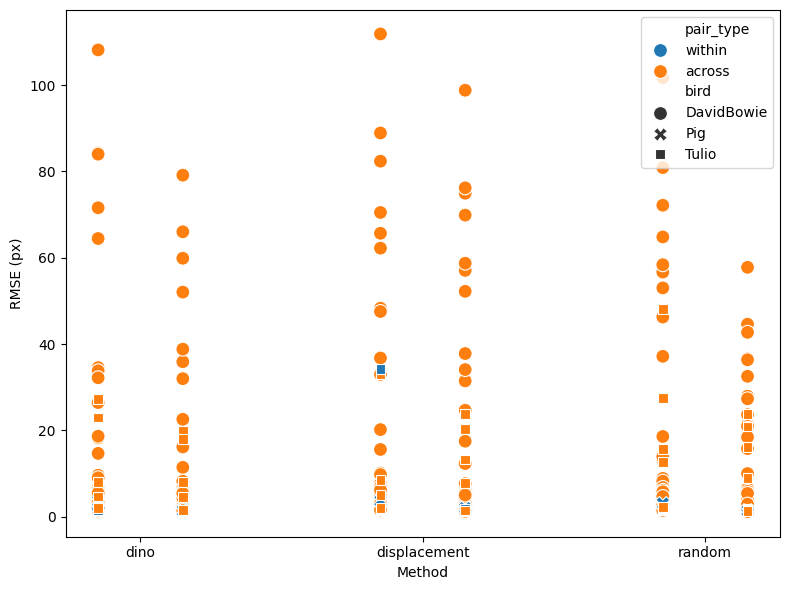

In [9]:

plot_df = scores_df.copy()

methods = plot_df["method"].unique()
method_to_x = {m: i for i, m in enumerate(methods)}
plot_df["x"] = plot_df["method"].map(method_to_x)

# Create two side-by-side offsets based on nframes
nframes_values = sorted(plot_df["nframes"].unique())
offsets = {
    nframes_values[0]: -0.15,
    nframes_values[1]: 0.15,
}

plot_df["x_plot"] = plot_df["x"] + plot_df["nframes"].map(offsets)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="x_plot",
    y="rmse_px",
    hue="pair_type",
    style="bird",
    s=100,
)

plt.xticks(range(len(methods)), methods)
plt.xlabel("Method")
plt.ylabel("RMSE (px)")
plt.legend(title="")
plt.tight_layout()
plt.show()



In [10]:

summary = (
    scores_df
    .groupby(["method"])["rmse_px"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method
dino            14.47 ± 22.67
displacement    18.81 ± 26.61
random          15.61 ± 21.23
Name: mean_std, dtype: object


In [11]:
method_pair_table = (
    scores_df
    .groupby(["method", "pair_type"])["rmse_px"]
    .agg(mean="mean", std="std", n="count")
    .reset_index()
)

summary = (
    scores_df
    .groupby(["method", "pair_type"])["rmse_px"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

summary = (
    scores_df
    .groupby(["method", "bird"])["rmse_px"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method        pair_type
dino          across       18.08 ± 24.46
              within         1.47 ± 0.61
displacement  across       23.11 ± 28.41
              within         3.32 ± 7.30
random        across       19.42 ± 22.58
              within         1.90 ± 0.87
Name: mean_std, dtype: object
method        bird      
dino          DavidBowie    16.61 ± 24.88
              Pig             2.53 ± 1.61
              Tulio           7.20 ± 8.61
displacement  DavidBowie    21.26 ± 29.00
              Pig             2.83 ± 1.18
              Tulio         10.76 ± 12.45
random        DavidBowie    17.25 ± 22.88
              Pig             2.23 ± 1.17
              Tulio         10.55 ± 12.94
Name: mean_std, dtype: object


In [12]:
summary = (
    scores_df
    .groupby(["method", "pair_type", "bird"])["rmse_px"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method        pair_type  bird      
dino          across     DavidBowie    19.68 ± 26.22
                         Tulio          10.04 ± 9.39
              within     DavidBowie      1.27 ± 0.33
                         Pig             2.53 ± 1.61
                         Tulio           1.52 ± 0.36
displacement  across     DavidBowie    25.20 ± 30.29
                         Tulio         12.66 ± 12.13
              within     DavidBowie      1.59 ± 0.84
                         Pig             2.83 ± 1.18
                         Tulio          6.95 ± 13.33
random        across     DavidBowie    20.30 ± 23.94
                         Tulio         15.06 ± 13.87
              within     DavidBowie      2.02 ± 1.02
                         Pig             2.23 ± 1.17
                         Tulio           1.54 ± 0.32
Name: mean_std, dtype: object


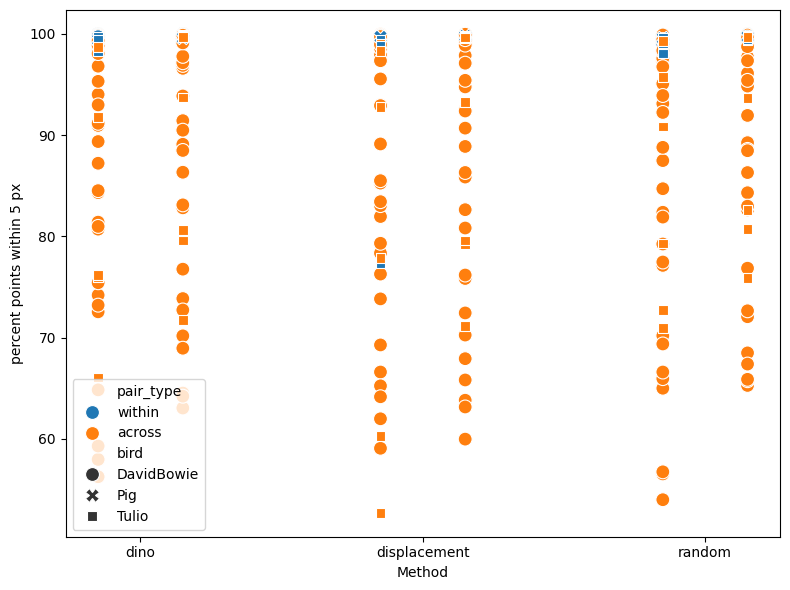

In [13]:
plot_df = scores_df.copy()

methods = plot_df["method"].unique()
method_to_x = {m: i for i, m in enumerate(methods)}
plot_df["x"] = plot_df["method"].map(method_to_x)

# Create two side-by-side offsets based on nframes
nframes_values = sorted(plot_df["nframes"].unique())
offsets = {
    nframes_values[0]: -0.15,
    nframes_values[1]: 0.15,
}

plot_df["x_plot"] = plot_df["x"] + plot_df["nframes"].map(offsets)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="x_plot",
    y="percent_points_within_threshold",
    hue="pair_type",
    style="bird",
    s=100,
)

plt.xticks(range(len(methods)), methods)
plt.xlabel("Method")
plt.ylabel("percent points within 5 px")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [14]:

summary = (
    scores_df
    .groupby(["method"])["percent_points_within_threshold"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary)

                   mean        std       mean_std
method                                           
dino          89.544639  12.623525  89.54 ± 12.62
displacement  88.541960  13.515700  88.54 ± 13.52
random        88.878832  12.964790  88.88 ± 12.96


In [15]:
summary = (
    scores_df
    .groupby(["method", "pair_type"])["percent_points_within_threshold"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method        pair_type
dino          across       86.72 ± 12.92
              within        99.72 ± 0.38
displacement  across       85.74 ± 13.82
              within        98.61 ± 5.01
random        across       85.92 ± 13.21
              within        99.53 ± 0.43
Name: mean_std, dtype: object


In [16]:
summary = (
    scores_df
    .groupby(["method", "bird"])["percent_points_within_threshold"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

summary = (
    scores_df
    .groupby(["method", "pair_type"])["percent_points_within_threshold"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method        bird      
dino          DavidBowie    89.03 ± 12.94
              Pig            99.52 ± 0.14
              Tulio         90.50 ± 11.83
displacement  DavidBowie    88.45 ± 13.26
              Pig            99.74 ± 0.06
              Tulio         87.67 ± 15.08
random        DavidBowie    88.07 ± 13.53
              Pig            99.65 ± 0.12
              Tulio         90.92 ± 10.67
Name: mean_std, dtype: object
method        pair_type
dino          across       86.72 ± 12.92
              within        99.72 ± 0.38
displacement  across       85.74 ± 13.82
              within        98.61 ± 5.01
random        across       85.92 ± 13.21
              within        99.53 ± 0.43
Name: mean_std, dtype: object


In [17]:
#FIXME: note that there are different number of points

plot_df = scores_df.copy()

methods = plot_df["method"].unique()
method_to_x = {m: i for i, m in enumerate(methods)}
plot_df["x"] = plot_df["method"].map(method_to_x)

# Create two side-by-side offsets based on nframes
nframes_values = sorted(plot_df["nframes"].unique())
offsets = {
    nframes_values[0]: -0.15,
    nframes_values[1]: 0.15,
}

plot_df["x_plot"] = plot_df["x"] + plot_df["nframes"].map(offsets)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="x_plot",
    y="mean_percent_preds_win_frame",
    hue="pair_type",
    style="bird",
    s=100,
)

plt.xticks(range(len(methods)), methods)
plt.xlabel("Method")
plt.ylabel("Percent Number of Preds within 5px: \n Across both images")
plt.legend(title="")
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `mean_percent_preds_win_frame` for `y`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

In [18]:

summary = (
    scores_df
    .groupby(["method"])["mean_percent_preds_win_frame"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary)

KeyError: 'Column not found: mean_percent_preds_win_frame'

In [42]:
summary = (
    scores_df
    .groupby(["method", "pair_type"])["mean_percent_preds_win_frame"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

summary = (
    scores_df
    .groupby(["method", "bird"])["mean_percent_preds_win_frame"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method        pair_type
dino          across       61.43 ± 18.13
              within        99.83 ± 0.18
displacement  across       59.35 ± 16.18
              within        99.75 ± 0.22
random        across       58.86 ± 18.98
              within        99.66 ± 0.27
Name: mean_std, dtype: object
method        bird      
dino          DavidBowie    71.55 ± 25.74
              Tulio         86.66 ± 14.50
displacement  DavidBowie    69.49 ± 25.34
              Tulio         87.04 ± 13.85
random        DavidBowie    68.88 ± 27.13
              Tulio         87.31 ± 13.38
Name: mean_std, dtype: object


### ----------------------------------------------------------------------------------------------

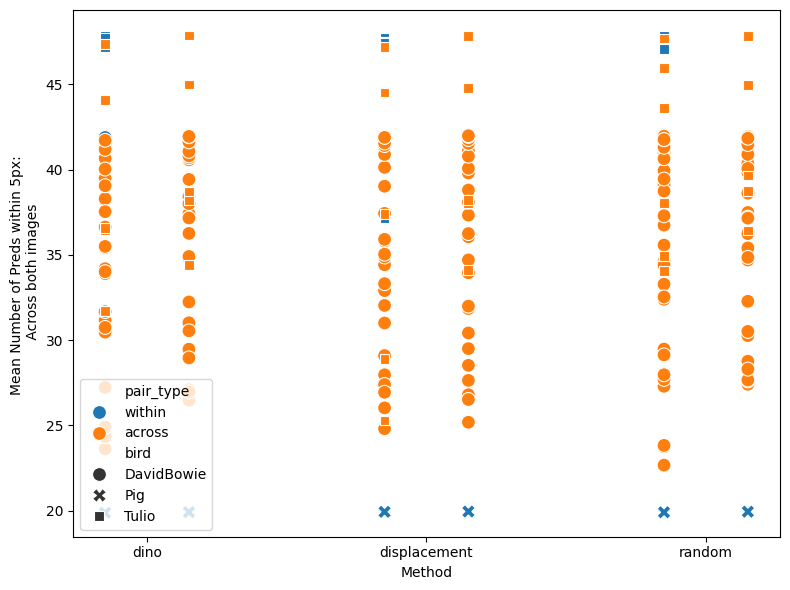

In [19]:
#FIXME: note that there are different number of points

plot_df = scores_df.copy()

methods = plot_df["method"].unique()
method_to_x = {m: i for i, m in enumerate(methods)}
plot_df["x"] = plot_df["method"].map(method_to_x)

# Create two side-by-side offsets based on nframes
nframes_values = sorted(plot_df["nframes"].unique())
offsets = {
    nframes_values[0]: -0.15,
    nframes_values[1]: 0.15,
}

plot_df["x_plot"] = plot_df["x"] + plot_df["nframes"].map(offsets)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="x_plot",
    y="mean_n_predictions_within_threshold_per_frame",
    hue="pair_type",
    style="bird",
    s=100,
)

plt.xticks(range(len(methods)), methods)
plt.xlabel("Method")
plt.ylabel("Mean Number of Preds within 5px: \n Across both images")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [20]:

summary = (
    scores_df
    .groupby(["method"])["mean_n_predictions_within_threshold_per_frame"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method
dino            38.20 ± 6.51
displacement    37.74 ± 6.71
random          37.92 ± 6.66
Name: mean_std, dtype: object


In [21]:
summary = (
    scores_df
    .groupby(["method", 'pair_type'])["mean_n_predictions_within_threshold_per_frame"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

summary = (
    scores_df
    .groupby(["method", 'bird'])["mean_n_predictions_within_threshold_per_frame"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method        pair_type
dino          across       37.28 ± 5.83
              within       41.48 ± 7.84
displacement  across       36.85 ± 6.16
              within       40.95 ± 7.74
random        across       36.95 ± 6.02
              within       41.40 ± 7.81
Name: mean_std, dtype: object
method        bird      
dino          DavidBowie    37.39 ± 5.43
              Pig           19.90 ± 0.03
              Tulio         43.44 ± 5.68
displacement  DavidBowie    37.15 ± 5.57
              Pig           19.95 ± 0.01
              Tulio         42.08 ± 7.24
random        DavidBowie    36.99 ± 5.68
              Pig           19.93 ± 0.02
              Tulio         43.64 ± 5.12
Name: mean_std, dtype: object


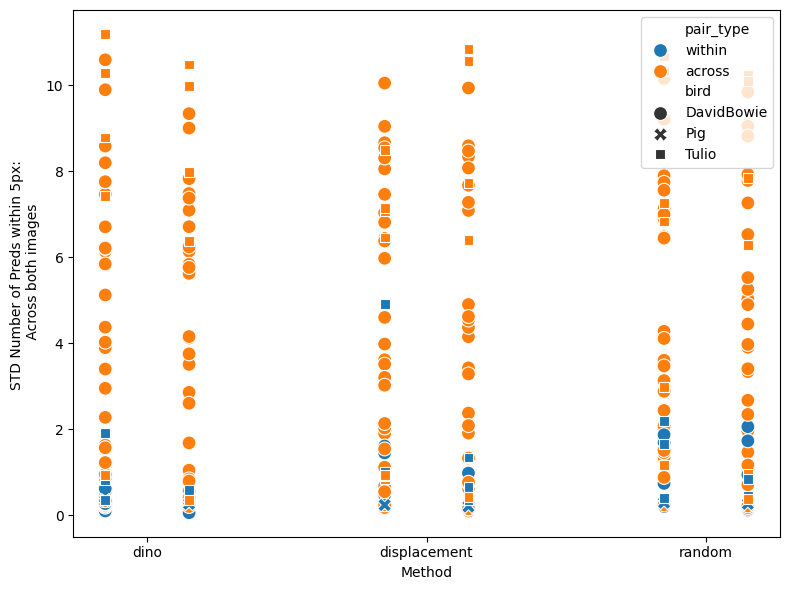

In [22]:
#FIXME: note that there are different number of points

plot_df = scores_df.copy()

methods = plot_df["method"].unique()
method_to_x = {m: i for i, m in enumerate(methods)}
plot_df["x"] = plot_df["method"].map(method_to_x)

# Create two side-by-side offsets based on nframes
nframes_values = sorted(plot_df["nframes"].unique())
offsets = {
    nframes_values[0]: -0.15,
    nframes_values[1]: 0.15,
}

plot_df["x_plot"] = plot_df["x"] + plot_df["nframes"].map(offsets)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="x_plot",
    y="std_n_predictions_within_threshold_per_frame",
    hue="pair_type",
    style="bird",
    s=100,
)

plt.xticks(range(len(methods)), methods)
plt.xlabel("Method")
plt.ylabel("STD Number of Preds within 5px: \n Across both images")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [23]:
summary = (
    scores_df
    .groupby(["method"])["std_n_predictions_within_threshold_per_frame"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method
dino            3.47 ± 3.42
displacement    3.59 ± 3.31
random          3.84 ± 3.29
Name: mean_std, dtype: object


In [24]:
summary = (
    scores_df
    .groupby(["method", 'bird'])["std_n_predictions_within_threshold_per_frame"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method        bird      
dino          DavidBowie    3.30 ± 3.13
              Pig           0.30 ± 0.05
              Tulio         4.48 ± 4.38
displacement  DavidBowie    3.50 ± 3.18
              Pig           0.22 ± 0.02
              Tulio         4.30 ± 3.79
random        DavidBowie    3.78 ± 3.07
              Pig           0.28 ± 0.02
              Tulio         4.50 ± 4.09
Name: mean_std, dtype: object


In [25]:
summary = (
    scores_df
    .groupby(["method", 'pair_type'])["std_n_predictions_within_threshold_per_frame"]
    .agg(mean="mean", std="std")
    .assign(
        mean_std=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )
)

print(summary["mean_std"])

method        pair_type
dino          across       4.32 ± 3.39
              within       0.40 ± 0.41
displacement  across       4.36 ± 3.30
              within       0.79 ± 1.08
random        across       4.66 ± 3.26
              within       0.90 ± 0.71
Name: mean_std, dtype: object


## Blob-Detect Final Correction Experiment

Run baseline + blob-detect corrected predictions for all within/across evaluations.

- Writes corrected prediction files as `*-blobDetect.csv`
- Saves score + comparison CSVs under `evaluation_results`
- Shows side-by-side metric comparison for:
  - RMSE
  - Percent points within threshold
  - Percent frames with all points within threshold
  - Mean number of points within threshold per frame

In [ ]:
## Need to remove predictions on DB_T{num1 + num 2}
## Need to remove predictions from DB_T{num1 + num 2} to both num 1 and num 2, so we just do the left out one!

run_all_birds = bool(globals().get("RUN_ALL_BIRDS", False))
# threshold_px = float(globals().get("THRESHOLD_PX", 5.0))
threshold_px = 3
fps_for_inference = int(globals().get("FPS_FOR_STACK_TO_AVI", 500))
batchsize_for_inference = int(globals().get("BATCHSIZE_FOR_INFERENCE", 16))
delete_preds = bool(globals().get("DELETE_INTERMEDIATE_PREDICTIONS", False))
force_rebuild = bool(globals().get("FORCE_REBUILD_AVI", True))
REPREDICT = False    # Only set to true if you really want to repredict on all
if run_all_birds:
    blob_eval_out = evaluate_within_across_blobdetect_all_birds(
        data_root=DATA_ROOT,
        build_manifest_path=BUILD_MANIFEST_PATH,
        birds=None,
        threshold_px=threshold_px,
        fps=fps_for_inference,
        batchsize=batchsize_for_inference,
        delete_intermediate_predictions=delete_preds,
        force_rebuild_avi=force_rebuild,
        repredict_all = REPREDICT,
    )
    blob_scores_df = blob_eval_out["combined_scores_df"]
    blob_compare_df = blob_eval_out["combined_comparison_df"]
else:
    bird_to_eval = str(globals().get("BIRD_TO_EVAL", "DavidBowie"))
    blob_eval_out = evaluate_within_across_blobdetect_for_bird(
        bird=bird_to_eval,
        data_root=DATA_ROOT,
        build_manifest_path=BUILD_MANIFEST_PATH,
        threshold_px=threshold_px,
        fps=fps_for_inference,
        batchsize=batchsize_for_inference,
        delete_intermediate_predictions=delete_preds,
        force_rebuild_avi=force_rebuild,
    )
    blob_scores_df = blob_eval_out["scores_df"]
    blob_compare_df = blob_eval_out["comparison_df"]

ok_scores = blob_scores_df[blob_scores_df["status"] == "ok"].copy()

metric_cols = [
    "rmse_px",
    "percent_points_within_threshold",
    "percent_frames_all_points_within_threshold",
    "mean_n_predictions_within_threshold_per_frame",
]

variant_summary = (
    ok_scores.groupby("prediction_variant", as_index=False)[metric_cols]
    .mean(numeric_only=True)
    .sort_values("prediction_variant")
)

print("Average metric summary by prediction variant:")
display(variant_summary)

if blob_compare_df.empty:
    print("No baseline/blobDetect comparison rows were generated.")
else:
    compare_view_cols = [
        "bird",
        "train_trial",
        "eval_trial",
        "method",
        "nframes",
        "rmse_px_baseline",
        "rmse_px_blobDetect",
        "delta_rmse_px_blob_minus_base",
        "percent_points_within_threshold_baseline",
        "percent_points_within_threshold_blobDetect",
        "delta_percent_points_within_threshold_blob_minus_base",
        "percent_frames_all_points_within_threshold_baseline",
        "percent_frames_all_points_within_threshold_blobDetect",
        "delta_percent_frames_all_points_within_threshold_blob_minus_base",
        "mean_n_predictions_within_threshold_per_frame_baseline",
        "mean_n_predictions_within_threshold_per_frame_blobDetect",
        "delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base",
    ]
    compare_view = blob_compare_df[compare_view_cols].sort_values(
        ["bird", "eval_trial", "method", "nframes", "train_trial"],
        kind="mergesort",
    )
    print("Per-run baseline vs blob-detect comparison:")
    display(compare_view)

if not run_all_birds:
    print("Saved combined scores CSV:", blob_eval_out["full_scores_csv"])
    print("Saved comparison CSV:", blob_eval_out["full_comparison_csv"])
    print("Saved point-errors CSV:", blob_eval_out["full_errors_csv"])


In [38]:
dlc_path = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\Code-Testing\DLCsupport.py")
sys.path.append(str(dlc_path))

from DLCsupport import BIRD_BODYPARTS


# Create a denominator for each row based on the bird
compare_view["n_keypoints"] = (
    compare_view["bird"]
    .map(lambda bird: len(BIRD_BODYPARTS[bird]) * 2)
)

compare_view["mean_percent_preds_win_frame_baseline"] = (
    100
    * compare_view["mean_n_predictions_within_threshold_per_frame_baseline"]
    / compare_view["n_keypoints"]
)

compare_view["mean_percent_preds_win_frame_blobDetect"] = (
    100
    * compare_view["mean_n_predictions_within_threshold_per_frame_blobDetect"]
    / compare_view["n_keypoints"]
)

compare_view["delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base"] = (
    compare_view["mean_percent_preds_win_frame_blobDetect"]
    - compare_view["mean_percent_preds_win_frame_baseline"]
)


In [39]:
compare_view["pair_type"] = np.where(
    compare_view["train_trial"] != compare_view["eval_trial"],
    "across",
    "within"
)


In [33]:
compare_view_copy = compare_view.copy()


In [45]:
compare_view = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\OverallModelEfforts_blobDetect_Whole.csv").iloc[:, 1:]

In [58]:

def extract_numbers(x):
    """Return a list of integers from a value."""
    return [int(n) for n in re.findall(r"\d+", str(x))]

def keep_row(row):
    train = row["train_trial"]
    eval_ = row["eval_trial"]

    # Skip if eval_trial has more than 2 numbers
    if int(eval_) > 45:
        return False

    # Skip if train_trial has >2 numbers AND contains any eval_trial number
    train_str = str(train)
    eval_str = str(eval_)
    # if int(train) > 99 and (eval_str in train_str):
    #     return False

    return True

filtered_compare_df = compare_view[compare_view.apply(keep_row, axis=1)].copy()



In [59]:
filtered_compare_df["CombinedModel"] = (
    filtered_compare_df["train_trial"].apply(lambda x: x > 45)
)
filtered_compare_df["eval_trial"] = filtered_compare_df["eval_trial"].astype(int)

In [60]:
# filtered_compare_df["pair_type"] = np.where(
#     filtered_compare_df["train_trial"] != filtered_compare_df["eval_trial"] or if int(train) > 99 and (eval_str in train_str):,
#     "across",
#     "within"
# )
train_str = filtered_compare_df["train_trial"].astype(str)
eval_str = filtered_compare_df["eval_trial"].astype(int).astype(str)


contains = [e in t for t, e in zip(train_str, eval_str)]

filtered_compare_df["pair_type"] = np.where(
    (filtered_compare_df["train_trial"] == filtered_compare_df["eval_trial"]) |
    (
        (filtered_compare_df["train_trial"] >= 45) &
        contains
    ),
    "within",
     "across"
)

C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_23792\2518263580.py:15: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  (filtered_compare_df["train_trial"] >= 45) &


In [45]:
filtered_compare_df.to_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\forplottingModelOverview_Whole.csv")

In [61]:
compare_view = filtered_compare_df.copy()

In [62]:
compare_view

,bird,train_trial,eval_trial,method,nframes,rmse_px_baseline,rmse_px_blobDetect,delta_rmse_px_blob_minus_base,percent_points_within_threshold_baseline,percent_points_within_threshold_blobDetect,...,percent_frames_all_points_within_threshold_blobDetect,delta_percent_frames_all_points_within_threshold_blob_minus_base,mean_n_predictions_within_threshold_per_frame_baseline,mean_n_predictions_within_threshold_per_frame_blobDetect,delta_mean_n_predictions_within_threshold_per_frame_blob_minus_base,n_keypoints,mean_percent_preds_win_frame_baseline,mean_percent_preds_win_frame_blobDetect,pair_type,CombinedModel
0,DavidBowie,15,15,dino,50,1.105921,1.848909,0.742988,99.142857,97.817460,...,54.333333,-17.666667,41.640000,41.083333,-1.325397,42,99.142857,97.817460,within,False
1,DavidBowie,16,15,dino,50,71.586593,71.649694,0.063101,43.849206,65.753968,...,0.333333,0.333333,18.416667,27.616667,21.904762,42,43.849206,65.753968,across,False
2,DavidBowie,17,15,dino,50,34.538364,34.732199,0.193835,51.412698,80.682540,...,1.333333,1.333333,21.593333,33.886667,29.269841,42,51.412698,80.682540,across,False
3,DavidBowie,1516,15,dino,50,1.343718,1.971434,0.627717,98.404762,98.007937,...,56.666667,3.000000,41.330000,41.163333,-0.396825,42,98.404762,98.007937,within,True
4,DavidBowie,1517,15,dino,50,1.580283,1.925161,0.344878,95.730159,97.849206,...,49.333333,31.666667,40.206667,41.096667,2.119048,42,95.730159,97.849206,within,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,Tulio,10,10,random,50,1.900176,2.162637,0.262460,95.215278,97.604167,...,41.000000,18.000000,45.703333,46.850000,2.388889,48,95.215278,97.604167,within,False
254,Tulio,105,10,random,50,1.658946,1.847423,0.188478,95.569444,97.569444,...,37.666667,15.000000,45.873333,46.833333,2.000000,48,95.569444,97.569444,within,True
255,Tulio,5,10,random,100,23.782063,23.943686,0.161623,57.798611,78.340278,...,4.333333,4.333333,27.743333,37.603333,20.541667,48,57.798611,78.340278,across,False
256,Tulio,10,10,random,100,1.189489,1.724436,0.534947,98.881944,98.027778,...,44.666667,-30.666667,47.463333,47.053333,-0.854167,48,98.881944,98.027778,within,False


In [63]:
Baseline = (
    compare_view
    .groupby(["method"])[ "rmse_px_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)



BlobDetect = (
    compare_view
    .groupby(["method"])[ "rmse_px_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        BlobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["BlobDetect"]]
)
summary = pd.concat([Baseline, BlobDetect], axis=1)
print("        RMSE For Each Suite Of Models")
print(summary)


        RMSE For Each Suite Of Models
                   Baseline     BlobDetect
method                                    
dino          12.61 ± 22.88  12.83 ± 22.79
displacement  16.72 ± 27.57  16.94 ± 27.46
random        15.53 ± 22.96  15.70 ± 22.82


In [64]:
Baseline = (
    compare_view
    .groupby(["method", "pair_type"])[ "rmse_px_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)



BlobDetect = (
    compare_view
    .groupby(["method", "pair_type"])[ "rmse_px_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        BlobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["BlobDetect"]]
)
summary = pd.concat([Baseline, BlobDetect], axis=1)

print(summary)

                             Baseline     BlobDetect
method       pair_type                              
dino         across     26.67 ± 29.17  26.71 ± 29.17
             within       1.57 ± 0.70    1.92 ± 0.60
displacement across     34.25 ± 33.91  34.30 ± 33.88
             within       2.95 ± 6.22    3.30 ± 6.08
random       across     32.23 ± 26.50  32.25 ± 26.40
             within       2.41 ± 2.23    2.70 ± 2.12


In [65]:
Baseline = (
    filtered_compare_df
    .groupby(["method", "pair_type", "CombinedModel"])[ "rmse_px_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)



BlobDetect = (
    filtered_compare_df
    .groupby(["method", "pair_type", "CombinedModel"])[ "rmse_px_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        BlobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["BlobDetect"]]
)
summary = pd.concat([Baseline, BlobDetect], axis=1)

print(summary)

                                           Baseline     BlobDetect
method       pair_type CombinedModel                              
dino         across    False          34.45 ± 30.84  34.49 ± 30.85
                       True             5.91 ± 2.77    5.97 ± 2.97
             within    False            1.45 ± 0.73    1.84 ± 0.61
                       True             1.65 ± 0.69    1.98 ± 0.61
displacement across    False          44.58 ± 34.45  44.57 ± 34.47
                       True             6.70 ± 4.06    6.91 ± 4.14
             within    False            4.44 ± 9.41    4.77 ± 9.21
                       True             1.84 ± 1.26    2.19 ± 1.19
random       across    False          41.68 ± 25.05  41.62 ± 25.02
                       True             7.03 ± 4.39    7.27 ± 4.46
             within    False            2.57 ± 2.93    2.84 ± 2.77
                       True             2.29 ± 1.63    2.59 ± 1.56


C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_23792\1478621097.py:43: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


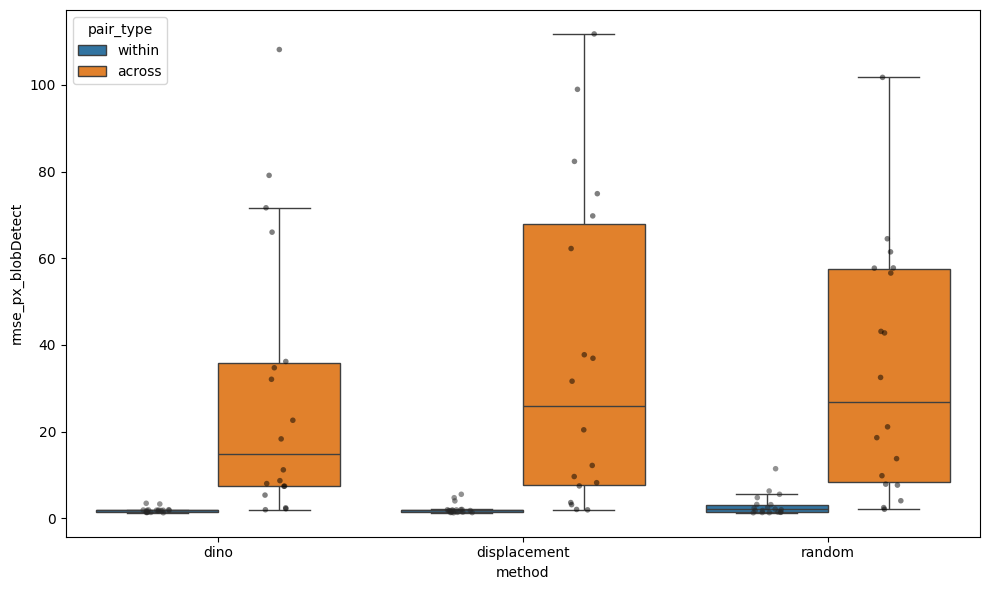

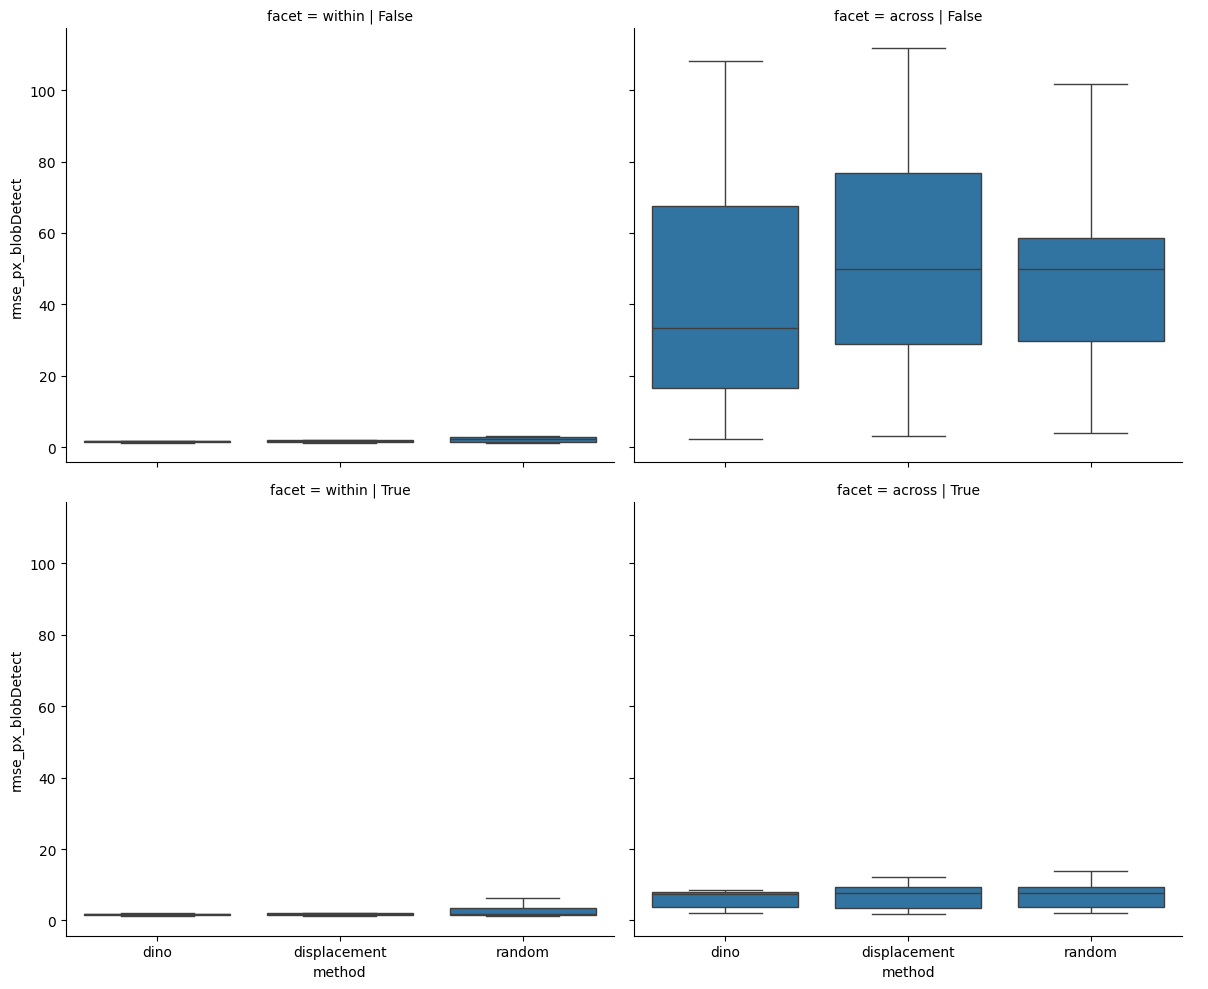

In [88]:
# plot_df = filtered_compare_df.copy()
# plot_df = plot_df[~plot_df["bird"].isin(["Tulio", "Pig"])]
# # Convert methods to x positions
# methods = plot_df["method"].unique()
# method_map = {m: i for i, m in enumerate(methods)}
# plot_df["x"] = plot_df["method"].map(method_map)

# # Add jitter
# plot_df["x"] += np.random.uniform(-0.15, 0.15, len(plot_df))

# fig, ax = plt.subplots(figsize=(10, 6))

# sns.scatterplot(
#     data=plot_df,
#     x="x",
#     y="rmse_px_blobDetect",
#     hue="pair_type",
#     style="CombinedModel",
#     s=80,
#     ax=ax,
# )

# ax.set_xticks(range(len(methods)))
# ax.set_xticklabels(methods)

# plt.show()

plot_df = filtered_compare_df.copy()
plot_df = plot_df[~plot_df["bird"].isin(["Tulio", "Pig"])]

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="pair_type",
    ax=ax,
    showfliers=False,   # optional
)

# Optional: overlay individual points
sns.stripplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    hue="pair_type",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    ax=ax,
)

# Remove the duplicate legend from the stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="pair_type")

plt.tight_layout()
plt.show()

plot_df["facet"] = (
    plot_df["pair_type"] + " | " +
    plot_df["CombinedModel"].astype(str)
)

g = sns.catplot(
    data=plot_df,
    x="method",
    y="rmse_px_blobDetect",
    col="facet",
    col_wrap=2,  # optional
    kind="box",
    height=5,
    aspect=1.2,
    showfliers=False,
)
plt.show()

In [70]:
Baseline = (
    compare_view
    .groupby(["method", "nframes", "pair_type"])[ "rmse_px_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)



BlobDetect = (
    compare_view
    .groupby(["method", "nframes", "pair_type"])[ "rmse_px_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        BlobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["BlobDetect"]]
)
summary = pd.concat([Baseline, BlobDetect], axis=1)

print(summary)


                                     Baseline     BlobDetect
method       nframes pair_type                              
dino         50      across     29.45 ± 32.90  29.51 ± 32.89
                     within       1.91 ± 0.85    2.15 ± 0.76
             100     across     23.89 ± 26.22  23.91 ± 26.22
                     within       1.22 ± 0.16    1.68 ± 0.26
displacement 50      across     34.48 ± 36.37  34.50 ± 36.35
                     within       4.40 ± 8.66    4.63 ± 8.50
             100     across     34.01 ± 33.03  34.10 ± 32.99
                     within       1.51 ± 0.91    1.96 ± 0.84
random       50      across     35.59 ± 32.20  35.53 ± 32.16
                     within       2.26 ± 1.26    2.48 ± 1.23
             100     across     28.87 ± 20.31  28.98 ± 20.15
                     within       2.56 ± 2.95    2.91 ± 2.78


In [71]:
baseline = (
    compare_view
    .groupby(["method"])["mean_percent_preds_win_frame_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["baseline"]]
)

blob = (
    compare_view
    .groupby(["method"])["mean_percent_preds_win_frame_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        blobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["blobDetect"]]
)
summary = pd.concat([baseline, blob], axis=1)
print("Percent of Points within 3px for each frame")
print("  ")
print(summary)

Percent of Points within 3px for each frame
  
                   baseline     blobDetect
method                                    
dino          81.89 ± 20.06  91.17 ± 10.37
displacement  80.23 ± 21.77  89.79 ± 11.58
random        79.53 ± 21.76  89.76 ± 11.25


In [72]:
baseline = (
    compare_view
    .groupby(["method", "pair_type"])["mean_percent_preds_win_frame_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)

blob = (
    compare_view
    .groupby(["method", "pair_type"])["mean_percent_preds_win_frame_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        blobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["blobDetect"]]
)

summary = pd.concat([baseline, blob], axis=1)
print("   Percent of Points within 3px for each frame")
print("  ")
print(summary)

   Percent of Points within 3px for each frame
  
                             Baseline     blobDetect
method       pair_type                              
dino         across     61.84 ± 13.45  82.26 ± 10.10
             within      97.63 ± 2.19   98.18 ± 0.64
displacement across     59.66 ± 14.60  79.57 ± 10.54
             within      96.39 ± 8.89   97.83 ± 2.23
random       across     58.18 ± 13.96   79.55 ± 9.92
             within      96.31 ± 6.66   97.78 ± 1.24


In [73]:
baseline = (
    filtered_compare_df
    .groupby(["method", "pair_type", "CombinedModel"])["mean_percent_preds_win_frame_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)

blob = (
    filtered_compare_df
    .groupby(["method", "pair_type", "CombinedModel"])["mean_percent_preds_win_frame_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        blobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["blobDetect"]]
)

summary = pd.concat([baseline, blob], axis=1)
print("   Percent of Points within 3px for each frame")
print("  ")
print(summary)

   Percent of Points within 3px for each frame
  
                                           Baseline    blobDetect
method       pair_type CombinedModel                             
dino         across    False          57.20 ± 12.22  79.17 ± 9.94
                       True            74.22 ± 7.70  90.50 ± 4.44
             within    False           98.48 ± 1.10  98.39 ± 0.73
                       True            97.00 ± 2.59  98.02 ± 0.54
displacement across    False          53.30 ± 10.90  75.37 ± 8.95
                       True            76.64 ± 7.98  90.76 ± 4.46
             within    False          94.72 ± 13.49  97.55 ± 3.36
                       True            97.64 ± 2.24  98.03 ± 0.76
random       across    False           51.82 ± 9.79  75.29 ± 7.52
                       True            75.14 ± 7.48  90.93 ± 5.43
             within    False           95.34 ± 9.87  97.91 ± 1.55
                       True            97.04 ± 2.66  97.68 ± 1.00


C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_23792\3094094271.py:44: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


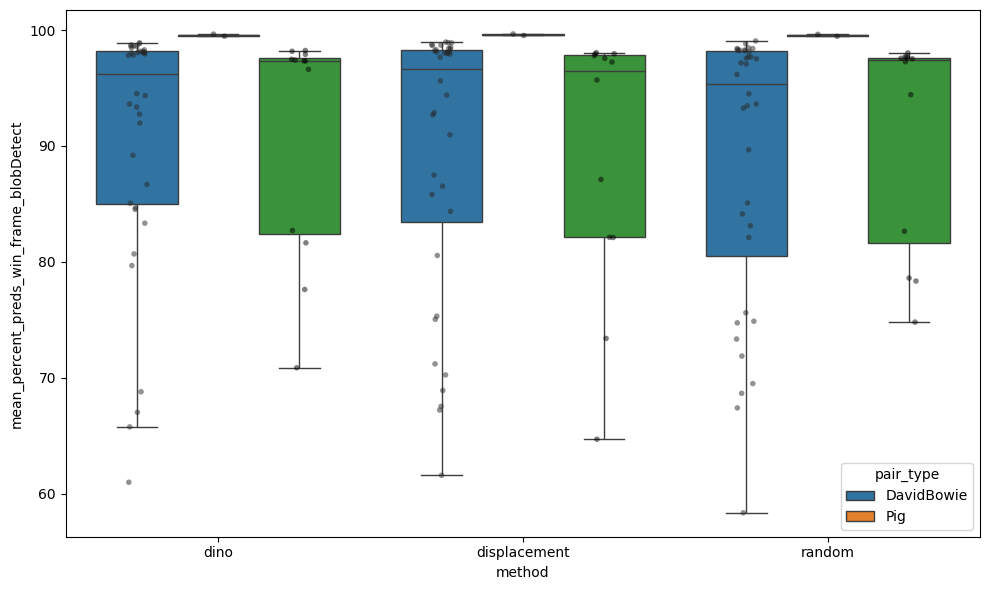

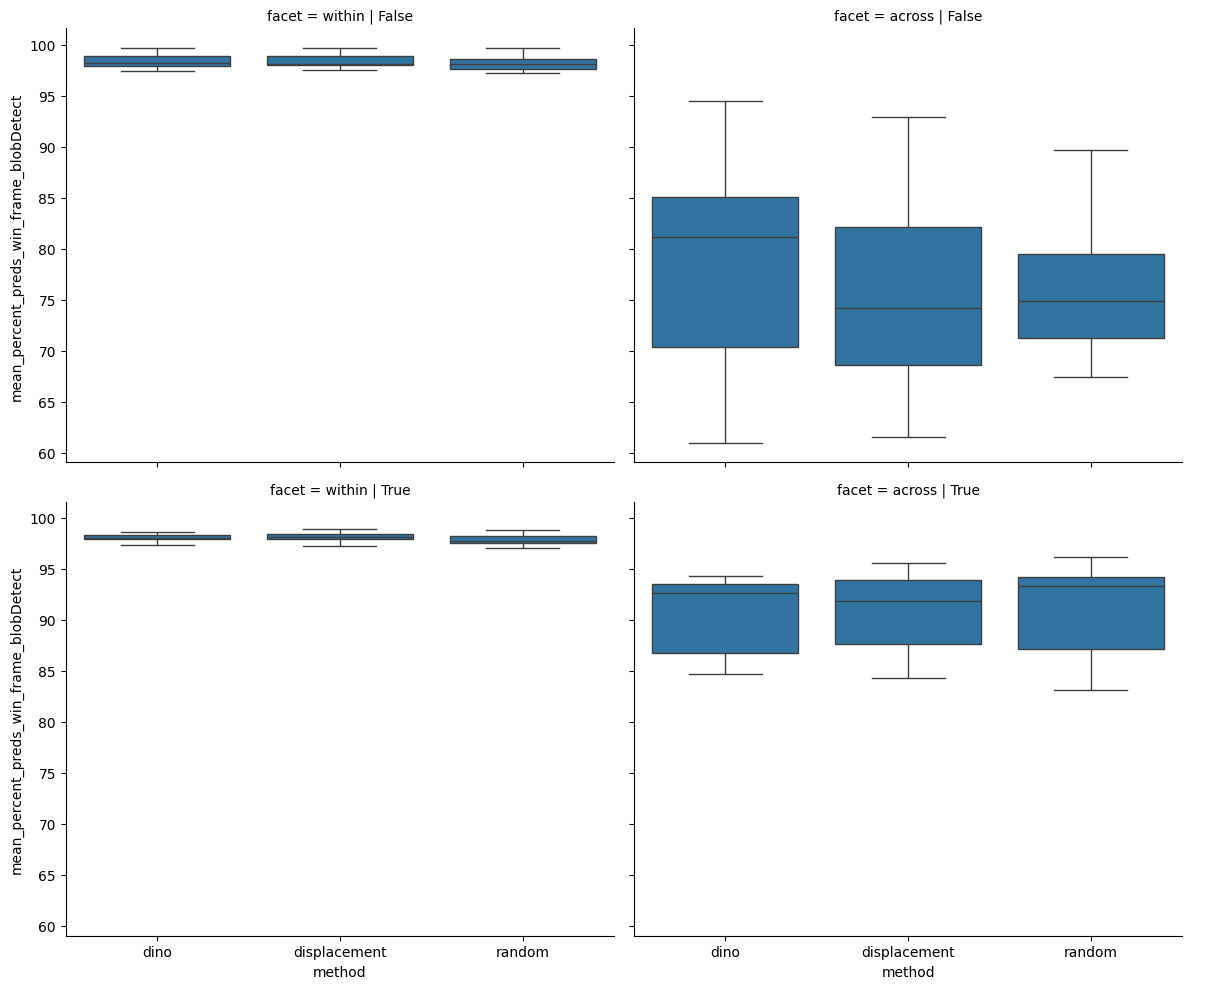

In [92]:
# plot_df = filtered_compare_df.copy()
# plot_df = plot_df[~plot_df["bird"].isin(["Tulio", "Pig"])]
# plot_df = plot_df[plot_df['pair_type'] != "within"]
# # Convert methods to x positions
# methods = plot_df["method"].unique()
# method_map = {m: i for i, m in enumerate(methods)}
# plot_df["x"] = plot_df["method"].map(method_map)

# # Add jitter
# plot_df["x"] += np.random.uniform(-0.15, 0.15, len(plot_df))

# fig, ax = plt.subplots(figsize=(10, 6))

# sns.scatterplot(
#     data=plot_df,
#     x="x",
#     y="mean_percent_preds_win_frame_blobDetect",
#     hue="eval_trial",
#     style="CombinedModel",
#     s=80,
#     ax=ax,
# )

# ax.set_xticks(range(len(methods)))
# ax.set_xticklabels(methods)

# plt.show()

plot_df = filtered_compare_df.copy()
# plot_df = plot_df[~plot_df["bird"].isin(["Tulio", "Pig"])]

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=plot_df,
    x="method",
    y="mean_percent_preds_win_frame_blobDetect",
    hue="bird",
    ax=ax,
    showfliers=False,   # optional
)

# Optional: overlay individual points
sns.stripplot(
    data=plot_df,
    x="method",
    y="mean_percent_preds_win_frame_blobDetect",
    hue="bird",
    dodge=True,
    alpha=0.5,
    size=4,
    color="black",
    ax=ax,
)

# Remove the duplicate legend from the stripplot
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="pair_type")

plt.tight_layout()
plt.show()

plot_df["facet"] = (
    plot_df["pair_type"] + " | " +
    plot_df["CombinedModel"].astype(str)
)

g = sns.catplot(
    data=plot_df,
    x="method",
    y="mean_percent_preds_win_frame_blobDetect",
    col="facet",
    col_wrap=2,  # optional
    kind="box",
    height=5,
    aspect=1.2,
    showfliers=False,
)


In [75]:
baseline = (
    compare_view
    .groupby(["method", "pair_type", "nframes"])["mean_percent_preds_win_frame_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)

blob = (
    compare_view
    .groupby(["method", "pair_type", "nframes"])["mean_percent_preds_win_frame_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        blobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["blobDetect"]]
)

summary = pd.concat([baseline, blob], axis=1)

print(summary)

                                     Baseline     blobDetect
method       pair_type nframes                              
dino         across    50       58.21 ± 12.70  80.98 ± 10.80
                       100      65.48 ± 13.77   83.54 ± 9.69
             within    50        96.45 ± 2.54   98.01 ± 0.67
                       100       98.82 ± 0.70   98.34 ± 0.60
displacement across    50       56.87 ± 15.66  78.47 ± 11.36
                       100      62.46 ± 13.61  80.67 ± 10.09
             within    50       93.95 ± 12.29   97.31 ± 3.06
                       100       98.83 ± 0.63   98.34 ± 0.61
random       across    50       57.83 ± 13.28  79.43 ± 11.35
                       100      58.52 ± 15.25   79.67 ± 8.81
             within    50        96.35 ± 2.56   97.65 ± 1.11
                       100       96.27 ± 9.25   97.91 ± 1.39


In [78]:

baseline = (
    compare_view
    .groupby(["method"])["percent_points_within_threshold_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)

blob = (
    compare_view
    .groupby(["method"])["percent_points_within_threshold_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        blobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["blobDetect"]]
)

summary = pd.concat([baseline, blob], axis=1)
print("    Percent of Points within 3 pixels")
print(summary)

    Percent of Points within 3 pixels
                   Baseline     blobDetect
method                                    
dino          81.89 ± 20.06  91.17 ± 10.37
displacement  80.23 ± 21.77  89.79 ± 11.58
random        79.53 ± 21.76  89.76 ± 11.25


In [79]:

baseline = (
    compare_view
    .groupby(["method", "pair_type"])["percent_points_within_threshold_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)

blob = (
    compare_view
    .groupby(["method", "pair_type"])["percent_points_within_threshold_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        blobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["blobDetect"]]
)

summary = pd.concat([baseline, blob], axis=1)
print("        Percent of Points within 5 pixels")
print(" ")
print(summary)

        Percent of Points within 5 pixels
 
                             Baseline     blobDetect
method       pair_type                              
dino         across     61.84 ± 13.45  82.26 ± 10.10
             within      97.63 ± 2.19   98.18 ± 0.64
displacement across     59.66 ± 14.60  79.57 ± 10.54
             within      96.39 ± 8.89   97.83 ± 2.23
random       across     58.18 ± 13.96   79.55 ± 9.92
             within      96.31 ± 6.66   97.78 ± 1.24


In [80]:

baseline = (
    compare_view
    .groupby(["method", "nframes"])["percent_points_within_threshold_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)

blob = (
    compare_view
    .groupby(["method", "nframes"])["percent_points_within_threshold_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        blobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["blobDetect"]]
)

summary = pd.concat([baseline, blob], axis=1)

print(summary)

                           Baseline     blobDetect
method       nframes                              
dino         50       79.62 ± 21.12  90.52 ± 11.11
             100      84.15 ± 19.09   91.83 ± 9.77
displacement 50       77.64 ± 23.17  89.02 ± 12.25
             100      82.82 ± 20.42  90.57 ± 11.08
random       50       79.40 ± 21.39  89.64 ± 11.81
             100      79.66 ± 22.56  89.88 ± 10.90


In [81]:

baseline = (
    compare_view
    .groupby(["method", "pair_type", "nframes"])["percent_points_within_threshold_baseline"]
    .agg(mean="mean", std="std")
    .assign(
        Baseline=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["Baseline"]]
)

blob = (
    compare_view
    .groupby(["method", "pair_type", "nframes"])["percent_points_within_threshold_blobDetect"]
    .agg(mean="mean", std="std")
    .assign(
        blobDetect=lambda df: df["mean"].map("{:.2f}".format)
        + " ± "
        + df["std"].map("{:.2f}".format)
    )[["blobDetect"]]
)

summary = pd.concat([baseline, blob], axis=1)

print(summary)

                                     Baseline     blobDetect
method       pair_type nframes                              
dino         across    50       58.21 ± 12.70  80.98 ± 10.80
                       100      65.48 ± 13.77   83.54 ± 9.69
             within    50        96.45 ± 2.54   98.01 ± 0.67
                       100       98.82 ± 0.70   98.34 ± 0.60
displacement across    50       56.87 ± 15.66  78.47 ± 11.36
                       100      62.46 ± 13.61  80.67 ± 10.09
             within    50       93.95 ± 12.29   97.31 ± 3.06
                       100       98.83 ± 0.63   98.34 ± 0.61
random       across    50       57.83 ± 13.28  79.43 ± 11.35
                       100      58.52 ± 15.25   79.67 ± 8.81
             within    50        96.35 ± 2.56   97.65 ± 1.11
                       100       96.27 ± 9.25   97.91 ± 1.39


In [12]:
compare_view = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\OverallModelEfforts-blobdetect2.csv")

In [28]:
import matplotlib as mpl

# -----------------------------
# User controls
# -----------------------------
ERROR_VIEW = "baseline"   # "baseline" | "blobDetect" | "delta"
PAIR_TYPE = "within"      # optional filter if column exists
CAMERA_FOR_ERROR_EMBED = "Cam1"
METHODS_TO_SHOW = ("random", "displacement", "dino")

# Trial folder used for embedding background cloud
# Reuses your existing variable if present
trial_name_for_plot = globals().get("TRIAL_FOR_EMBED_VIS", "DB_T16")
trial_dir_for_plot = DATA_ROOT / trial_name_for_plot

# comparison dataframe source (already built earlier in your notebook)
# expected: compare_view or blob_compare_df
comparison_df = globals().get("compare_view", globals().get("blob_compare_df", None))
if comparison_df is None:
    raise RuntimeError("comparison df not found. Run blobdetect comparison cell first (compare_view or blob_compare_df).")

# point-level errors source (needed for true per-frame RMSE)
# try in-memory first, then CSV path from blob_eval_out
# point_errors_df = None
# if "blob_eval_out" in globals():
#     # print(blob_eval_out)
#     point_errors_df = blob_eval_out.get("point_errors_df", None)
#     # print(point_errors_df)
#     if point_errors_df is None:
#         errors_csv = blob_eval_out.get("full_errors_csv", None)
#         # print(errors_csv)
#         if errors_csv is not None and Path(errors_csv).exists():
#             point_errors_df = pd.read_csv(errors_csv)

In [45]:

def _frame_rmse_from_points(df_points: pd.DataFrame) -> pd.Series:
    err_col = "distance_px"
    # print(err_col)
    # if err_col is None:
    #     raise ValueError(f"No point-error column found in point errors df. Columns: {list(df_points.columns)}")

    frame_key = "frame_id"
    # if frame_key is None:
    #     raise ValueError(f"No frame identifier column found in point errors df. Columns: {list(df_points.columns)}")

    x = df_points.copy()
    x[err_col] = pd.to_numeric(x[err_col], errors="coerce")
    x = x.dropna(subset=[err_col])

    # RMSE per frame: sqrt(mean(err^2))
    rmse = x.groupby(frame_key)[err_col].apply(lambda s: float(np.sqrt(np.mean(np.square(s.to_numpy())))))
    rmse.name = "frame_rmse"
    return rmse

def _select_rows_for_method(df: pd.DataFrame, method: str, nframes: int, trial_name: int, pair_type: str | None):
    x = df.copy()
    if "method" in x.columns:
        x = x[x["method"].astype(str).str.lower().eq(method.lower())]
    if "nframes" in x.columns:
        x = x[pd.to_numeric(x["nframes"], errors="coerce").eq(int(nframes))]
    if "eval_trial" in x.columns:
        x = x[x["eval_trial"].astype(int).eq(int(trial_name))]
    if pair_type is not None and "pair_type" in x.columns:
        x = x[x["pair_type"].astype(str).str.lower().eq(pair_type.lower())]
    return x

def plot_error_colored_embeddings_1x3(
    trial_dir: Path,
    comparison_df: pd.DataFrame,
    axes: int | None,
    point_errors_df: pd.DataFrame | None,
    error_view: str = "baseline",
    nframes: int = 50,
    camera: str = "Cam1",
    methods=("random", "displacement", "dino"),
    batch_size: int = 32,
):
    if not trial_dir.exists():
        raise FileNotFoundError(f"Trial folder not found: {trial_dir}")

    complete_images = _list_images_sorted(trial_dir / "CompleteSet" / camera)
    test_images = _list_images_sorted(trial_dir / "test" / camera)
    if len(complete_images) == 0:
        raise RuntimeError(f"No complete-set images found: {trial_dir / 'CompleteSet' / camera}")
    if len(test_images) == 0:
        raise RuntimeError(f"No test images found: {trial_dir / 'test' / camera}")

    # Embeddings (all frames)
    model, transform, device = _build_dino_model_once(model_name=DINO_MODEL_NAME)
    emb = _compute_embeddings_with_model(
        complete_images,
        model=model,
        transform=transform,
        device=device,
        batch_size=batch_size,
    )

    if umap is not None:
        reducer = umap.UMAP(
            n_neighbors=UMAP_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_SEED,
        )
        emb2d = reducer.fit_transform(emb)
        xlab, ylab = "UMAP 1", "UMAP 2"
    else:
        from sklearn.decomposition import PCA
        emb2d = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(emb)
        xlab, ylab = "PC 1", "PC 2"

    complete_name_to_idx = {p.name: i for i, p in enumerate(complete_images)}
    test_names = [p.name for p in test_images]
    test_idx_global = np.asarray([complete_name_to_idx[n] for n in test_names if n in complete_name_to_idx], dtype=int)

    # Build per-method frame RMSE vectors for test frames
        # Build per-method frame RMSE vectors for test frames
    method_to_idx = {}
    method_to_vals = {}

    fallback_metric_col = {
        "baseline": "rmse_px_baseline",
        "blobDetect": "rmse_px_blobDetect",
        "delta": "delta_rmse_px_blob_minus_base",
    }[error_view]

    for method in methods:

        vals = None

        # Preferred: point-level frame RMSE
        if point_errors_df is not None:

            match = re.search(r"_T(\d+)", trial_dir.name)
            trial_num = int(match.group(1)) if match else None

            p = _select_rows_for_method(
                point_errors_df,
                method,
                nframes,
                trial_num,
                PAIR_TYPE,
            )

            if error_view in ("baseline", "blobDetect"):

                if "prediction_variant" in p.columns:
                    p = p[
                        p["prediction_variant"]
                        .astype(str)
                        .str.lower()
                        .eq(error_view.lower())
                    ]

                try:
                    frame_rmse = _frame_rmse_from_points(p)

                    # print(method)
                    # print(frame_rmse.head())
                    # print(frame_rmse.describe())

                    vals = []

                    for i_local, img_name in enumerate(test_names):

                        if img_name in frame_rmse.index:
                            vals.append(float(frame_rmse.loc[img_name]))
                        elif i_local in frame_rmse.index:
                            vals.append(float(frame_rmse.loc[i_local]))
                        else:
                            vals.append(np.nan)

                    vals = np.asarray(vals, dtype=float)

                except Exception as e:
                    print(e)
                    vals = None

            elif error_view == "delta":

                p0 = p.copy()
                p1 = p.copy()

                if "prediction_variant" in p.columns:
                    p0 = p0[
                        p0["prediction_variant"]
                        .astype(str)
                        .str.lower()
                        .eq("baseline")
                    ]

                    p1 = p1[
                        p1["prediction_variant"]
                        .astype(str)
                        .str.lower()
                        .eq("blobdetect")
                    ]

                try:

                    r0 = _frame_rmse_from_points(p0)
                    r1 = _frame_rmse_from_points(p1)

                    vals = []

                    for i_local, img_name in enumerate(test_names):

                        k_name = (
                            img_name
                            if img_name in r0.index or img_name in r1.index
                            else None
                        )

                        k_idx = (
                            i_local
                            if i_local in r0.index or i_local in r1.index
                            else None
                        )

                        v0 = (
                            float(r0.loc[k_name])
                            if (k_name is not None and k_name in r0.index)
                            else (
                                float(r0.loc[k_idx])
                                if (k_idx is not None and k_idx in r0.index)
                                else np.nan
                            )
                        )

                        v1 = (
                            float(r1.loc[k_name])
                            if (k_name is not None and k_name in r1.index)
                            else (
                                float(r1.loc[k_idx])
                                if (k_idx is not None and k_idx in r1.index)
                                else np.nan
                            )
                        )

                        vals.append(v1 - v0)

                    vals = np.asarray(vals, dtype=float)
                    vals = np.clip(vals, 0, None)

                except Exception as e:
                    print(e)
                    vals = None

        # Fallback: run-level scalar
        if vals is None:

            match = re.search(r"_T(\d+)", trial_dir.name)
            trial_num = int(match.group(1)) if match else None

            c = _select_rows_for_method(
                comparison_df,
                method,
                nframes,
                trial_num,
                PAIR_TYPE,
            )

            if fallback_metric_col not in c.columns or len(c) == 0:
                scalar = np.nan
            else:
                scalar = float(
                    pd.to_numeric(
                        c[fallback_metric_col],
                        errors="coerce",
                    ).mean()
                )

                if error_view == "delta":
                    scalar = max(0.0, scalar)

            vals = np.full(
                len(test_idx_global),
                scalar,
                dtype=float,
            )

        # print(method)
        # print(vals.shape)
        # print(np.nanmin(vals), np.nanmax(vals))
        # print(f"unique values = {len(np.unique(vals))}")

        valid = np.isfinite(vals)

        method_to_idx[method] = test_idx_global[valid]
        method_to_vals[method] = vals[valid]


    # ====================================================
    # Plot bird trial on rows, columns are selection method
    # ====================================================

    created_fig = False

    if axes is None:
        fig, axes = plt.subplots(
            1, 3,
            figsize=(18, 5),
            sharex=True,
            sharey=True,
        )
        own_figure = True
    else:
        fig = axes[0].figure
        own_figure = False
    cmap = plt.cm.Reds

    # Global color scale across all methods
    all_vals = np.concatenate(
        [v for v in method_to_vals.values() if len(v) > 0]
    )

    global_vmax = np.nanmax(all_vals)
    if not np.isfinite(global_vmax) or global_vmax <= 0:
        global_vmax = 1.0

    norm = mpl.colors.Normalize(vmin=0.0, vmax=global_vmax)



    for ax, method in zip(axes, methods):

        ax.scatter(
            emb2d[:, 0],
            emb2d[:, 1],
            s=12,
            c="#1b1b1b",
            alpha=0.18,
            linewidths=0,
        )

        idx = method_to_idx.get(method, np.asarray([], dtype=int))
        vals = method_to_vals.get(method, np.asarray([], dtype=float))

        if len(idx) > 0:

            vmax = np.nanmax(vals)

            if not np.isfinite(vmax) or vmax <= 0:
                vmax = 1.0

            norm = mpl.colors.Normalize(
                vmin=0.0,
                vmax=vmax,
            )

            sc = ax.scatter(
                emb2d[idx, 0],
                emb2d[idx, 1],
                c=idx,
                cmap=cmap,
                # norm=norm,
                s=34,
                edgecolors="black",
                linewidths=0.25,
                alpha=0.95,
            )

                    # If you want unique color bars
            # cbar = fig.colorbar(
            #     sc,
            #     ax=ax,
            #     fraction=0.046,
            #     pad=0.04,
            # )

            # cbar.set_label(f"Frame RMSE ({error_view})")

        ax.set_title(method)
        ax.set_xlabel(xlab)
    
    # fig.colorbar(
    #     mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    #     ax=axes,
    #     fraction=0.025,
    #     pad=0.02,
    #     label=f"Frame RMSE ({error_view})",
    # )
    axes[0].set_ylabel(ylab)
    fig.suptitle(
            f"{trial_dir.name} | {camera} | nframes={nframes} | pair={PAIR_TYPE} | error={error_view}",
            y=1.02,
        )
    if own_figure:
        plt.tight_layout()
        plt.show()

In [5]:
point_errors_df_DB = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\DavidBowie_within_across_point_errors_with_blobDetect_20260715_160251.csv")

In [16]:
import matplotlib as mpl

# -----------------------------
# User controls
# -----------------------------
ERROR_VIEW = "baseline"   # "baseline" | "blobDetect" | "delta"
PAIR_TYPE = "within"      # optional filter if column exists
CAMERA_FOR_ERROR_EMBED = "Cam1"
METHODS_TO_SHOW = ("random", "displacement", "dino")

# Trial folder used for embedding background cloud
# Reuses your existing variable if present
trial_name_for_plot = globals().get("TRIAL_FOR_EMBED_VIS", "DB_T16")
trial_dir_for_plot = DATA_ROOT / trial_name_for_plot
trial_dir_for_plot = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T16")
print(trial_dir_for_plot)
# comparison dataframe source (already built earlier in your notebook)
# expected: compare_view or blob_compare_df
comparison_df = globals().get("compare_view", globals().get("blob_compare_df", None))
if comparison_df is None:
    raise RuntimeError("comparison df not found. Run blobdetect comparison cell first (compare_view or blob_compare_df).")

# # point-level errors source (needed for true per-frame RMSE)
# # try in-memory first, then CSV path from blob_eval_out
# point_errors_df = None
# if "blob_eval_out" in globals():
#     # print(blob_eval_out)
#     point_errors_df = blob_eval_out.get("point_errors_df", None)
#     # print(point_errors_df)
#     if point_errors_df is None:
#         errors_csv = blob_eval_out.get("full_errors_csv", None)
#         # print(errors_csv)
#         if errors_csv is not None and Path(errors_csv).exists():
#             point_errors_df = pd.read_csv(errors_csv)

C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\DB_T16


Plotting DB_T15...


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting DB_T16...


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Plotting DB_T17...


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


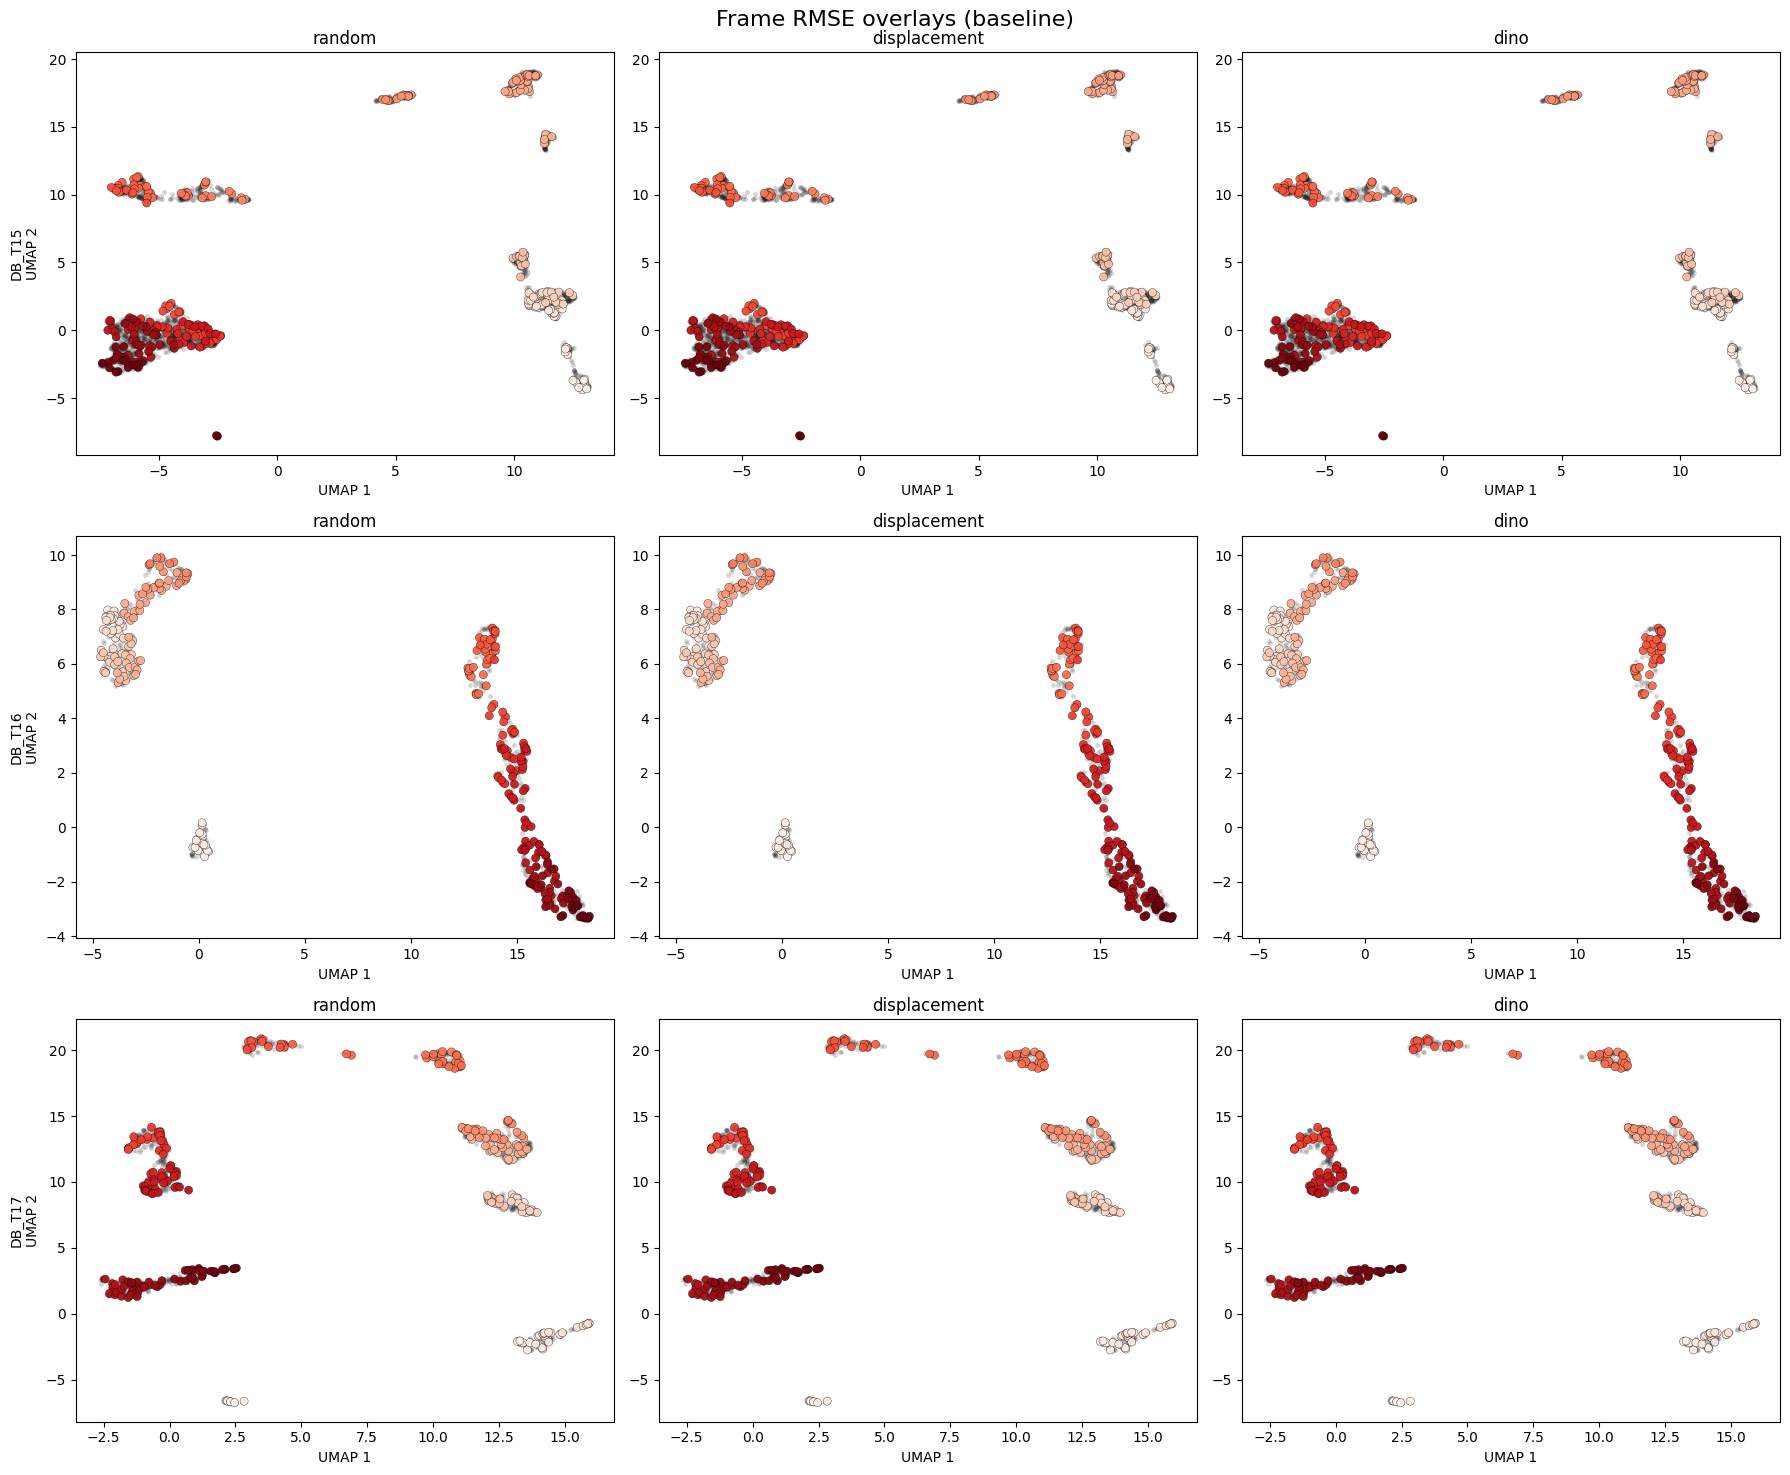

In [46]:
data_root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data"
)

dirs = [d for d in sorted(data_root.glob("DB_T*")) if d.is_dir()]

fig, axes = plt.subplots(
    len(dirs),
    3,
    figsize=(18, 5 * len(dirs)),
    facecolor="white",
)

if len(dirs) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, trial_dir in enumerate(dirs):

    print(f"Plotting {trial_dir.name}...")

    plot_error_colored_embeddings_1x3(
        trial_dir=trial_dir,
        comparison_df=comparison_df,
        point_errors_df=point_errors_df_DB,
        error_view=ERROR_VIEW,
        nframes=NFRAMES_FOR_METHOD_METADATA,
        camera=CAMERA_FOR_ERROR_EMBED,
        methods=METHODS_TO_SHOW,
        batch_size=DINO_BATCH_SIZE,
        axes=axes[row],          # <-- pass one row of axes
    )

    axes[row, 0].set_ylabel(f"{trial_dir.name}\nUMAP 2")

fig.suptitle(
    f"Frame RMSE overlays ({ERROR_VIEW})",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [7]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


def build_unified_embedding_results(
    trial_dirs,
    comparison_df,
    point_errors_df=None,
    error_view="baseline",
    camera="Cam1",
    methods=("random", "displacement", "dino"),
    nframes=50,
    batch_size=32,
):
    """
    Compute one global DINO+UMAP space over all trials.

    Returns
    -------
    results:
        {
          "across": {
              method: {
                  "xy": Nx2,
                  "vals": N
              }
          },
          "within": ...
        }

    """

    # -------------------------------------------------------
    # 1. Collect every image from every trial
    # -------------------------------------------------------

    all_complete_images = []
    trial_info = {}

    for trial_dir in trial_dirs:

        complete_images = _list_images_sorted(
            trial_dir / "CompleteSet" / camera
        )

        test_images = _list_images_sorted(
            trial_dir / "test" / camera
        )

        if len(complete_images) == 0:
            continue

        start_idx = len(all_complete_images)

        all_complete_images.extend(complete_images)

        trial_info[trial_dir] = {
            "complete_images": complete_images,
            "test_images": test_images,
            "offset": start_idx,
        }


    print(
        f"Total images for unified embedding: {len(all_complete_images)}"
    )


    # -------------------------------------------------------
    # 2. DINO embeddings ONCE
    # -------------------------------------------------------

    model, transform, device = _build_dino_model_once(
        model_name=DINO_MODEL_NAME
    )

    all_emb = _compute_embeddings_with_model(
        all_complete_images,
        model=model,
        transform=transform,
        device=device,
        batch_size=batch_size,
    )


    # -------------------------------------------------------
    # 3. One UMAP for everything
    # -------------------------------------------------------

    if umap is not None:

        reducer = umap.UMAP(
            n_neighbors=UMAP_NEIGHBORS,
            min_dist=UMAP_MIN_DIST,
            metric=UMAP_METRIC,
            random_state=RANDOM_SEED,
        )

        all_xy = reducer.fit_transform(all_emb)

        xlab = "UMAP 1"
        ylab = "UMAP 2"

    else:

        from sklearn.decomposition import PCA

        reducer = PCA(
            n_components=2,
            random_state=RANDOM_SEED,
        )

        all_xy = reducer.fit_transform(all_emb)

        xlab = "PC 1"
        ylab = "PC 2"


    # -------------------------------------------------------
    # 4. Accumulate results
    # -------------------------------------------------------

    results = {
        "across": defaultdict(
            lambda: {"xy": [], "vals": []}
        ),
        "within": defaultdict(
            lambda: {"xy": [], "vals": []}
        ),
    }


    fallback_metric_col = {
        "baseline": "rmse_px_baseline",
        "blobDetect": "rmse_px_blobDetect",
        "delta": "delta_rmse_px_blob_minus_base",
    }[error_view]


    pair_types = ["across", "within"]

    for trial_dir, info in trial_info.items():

        complete_offset = info["offset"]

        complete_name_to_idx = {
            p.name: complete_offset + i
            for i, p in enumerate(info["complete_images"])
        }

        test_names = [
            p.name
            for p in info["test_images"]
        ]

        test_idx_global = np.asarray(
            [
                complete_name_to_idx[n]
                for n in test_names
                if n in complete_name_to_idx
            ],
            dtype=int,
        )


        for pair in pair_types:

            print(
                trial_dir.name,
                "pair=",
                pair,
                "test frames=",
                len(test_idx_global),
            )


            for method in methods:

                vals = None


                if point_errors_df is not None:

                    match = re.search(
                        r"_T(\d+)",
                        trial_dir.name
                    )

                    trial_num = (
                        int(match.group(1))
                        if match
                        else None
                    )


                    p = _select_rows_for_method(
                        point_errors_df,
                        method,
                        nframes,
                        trial_num,
                        pair,        # <-- use loop variable
                    )


                    try:

                        if error_view in (
                            "baseline",
                            "blobDetect"
                        ):

                            if "prediction_variant" in p.columns:
                                p = p[
                                    p["prediction_variant"]
                                    .astype(str)
                                    .str.lower()
                                    .eq(error_view.lower())
                                ]


                            frame_rmse = _frame_rmse_from_points(p)


                            vals = []

                            for i, name in enumerate(test_names):

                                if name in frame_rmse.index:
                                    vals.append(
                                        float(frame_rmse.loc[name])
                                    )

                                elif i in frame_rmse.index:
                                    vals.append(
                                        float(frame_rmse.loc[i])
                                    )

                                else:
                                    vals.append(np.nan)


                            vals = np.asarray(vals)


                        elif error_view == "delta":

                            # keep your delta calculation here
                            pass


                    except Exception:
                        vals = None


                # fallback scalar

                if vals is None:

                    c = _select_rows_for_method(
                        comparison_df,
                        method,
                        nframes,
                        trial_num,
                        PAIR_TYPE,
                    )


                    scalar = (
                        pd.to_numeric(
                            c[fallback_metric_col],
                            errors="coerce",
                        ).mean()
                        if len(c)
                        else np.nan
                    )


                    vals = np.full(
                        len(test_idx_global),
                        scalar,
                    )


                valid = np.isfinite(vals)


                results[pair][method]["xy"].append(
                    all_xy[test_idx_global[valid]]
                )

                results[pair][method]["vals"].append(
                    vals[valid]
                )


    # concatenate

    for pair in results:
        for method in methods:

            xy_list = results[pair][method]["xy"]
            val_list = results[pair][method]["vals"]

            if len(xy_list) == 0:
                print(
                    f"No data for pair={pair}, method={method}"
                )

                results[pair][method]["xy"] = np.empty((0, 2))
                results[pair][method]["vals"] = np.empty((0,))

            else:
                results[pair][method]["xy"] = np.vstack(xy_list)
                results[pair][method]["vals"] = np.concatenate(val_list)

    return results, xlab, ylab

In [10]:
def plot_unified_embedding_results(
    results,
    methods=("random", "displacement", "dino"),
    xlab="UMAP 1",
    ylab="UMAP 2",
    error_view="baseline",
):

    fig, axes = plt.subplots(
        2,
        len(methods),
        figsize=(6 * len(methods), 10),
        sharex=True,
        sharey=True,
    )


    cmap = plt.cm.Reds


    # all_vals = np.concatenate(
    #     [
    #         results[p][m]["vals"]
    #         for p in ("across", "within")
    #         for m in methods
    #     ]
    # )


    # norm = mpl.colors.Normalize(
    #     vmin=0,
    #     vmax=np.nanmax(all_vals),
    # )
    all_vals = np.concatenate(
        [
            results[p][m]["vals"]
            for p in ("across", "within")
            for m in methods
            if len(results[p][m]["vals"]) > 0
        ]
    )

    # Remove invalid values
    all_vals = all_vals[np.isfinite(all_vals)]

    # Log scale cannot use zero
    positive_vals = all_vals[all_vals > 0]

    vmin = np.nanmin(positive_vals)
    vmax = np.nanmax(positive_vals)

    norm = mpl.colors.LogNorm(
        vmin=vmin,
        vmax=vmax,
    )

    for r, pair in enumerate(
        ["across", "within"]
    ):

        for c, method in enumerate(methods):

            ax = axes[r, c]

            xy = results[pair][method]["xy"]
            vals = results[pair][method]["vals"]

            if len(vals) > 0:

                # vals = results[pair][method]["vals"]

                # # avoid zeros on log scale
                # vals_plot = np.clip(
                #     vals,
                #     vmin,
                #     None,
                # )

                # ax.scatter(
                #     xy[:,0],
                #     xy[:,1],
                #     s=38,
                #     c=vals_plot,
                #     cmap=cmap,
                #     norm=norm,
                #     edgecolors="black",
                #     linewidths=0.25,
                #     alpha=0.9,
                # )
                n_frames = xy.shape[0]
                frame_idx = np.arange(n_frames)

                norm = mpl.colors.Normalize(
                    vmin=0,
                    vmax=n_frames - 1,
                )

                ax.scatter(
                    xy[:, 0],
                    xy[:, 1],
                    s=38,
                    c=frame_idx,
                    cmap=cmap,
                    norm=norm,
                    edgecolors="black",
                    linewidths=0.25,
                    alpha=0.9,
                )
            else:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    transform=ax.transAxes,
                    ha="center",
                    va="center",
                )


            if r == 0:
                ax.set_title(method)


            if c == 0:
                ax.set_ylabel(pair.capitalize())


            ax.grid(alpha=0.15)


    fig.supxlabel(xlab)
    fig.supylabel(ylab)


    # fig.colorbar(
    #     mpl.cm.ScalarMappable(
    #         norm=norm,
    #         cmap=cmap,
    #     ),
    #     ax=axes,
    #     fraction=0.025,
    #     pad=0.02,
    #     label=f"Frame RMSE ({error_view})",
    # )
    fig.colorbar(
        mpl.cm.ScalarMappable(
            norm=norm,
            cmap=cmap,
        ),
        ax=axes,
        fraction=0.025,
        pad=0.02,
        label=f"log(Frame RMSE) ({error_view})",
    )

    plt.tight_layout()
    plt.show()

Total images for unified embedding: 5302


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


DB_T15 pair= across test frames= 300
DB_T15 pair= within test frames= 300
DB_T16 pair= across test frames= 300
DB_T16 pair= within test frames= 300
DB_T17 pair= across test frames= 300
DB_T17 pair= within test frames= 300


C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_26720\3654609082.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


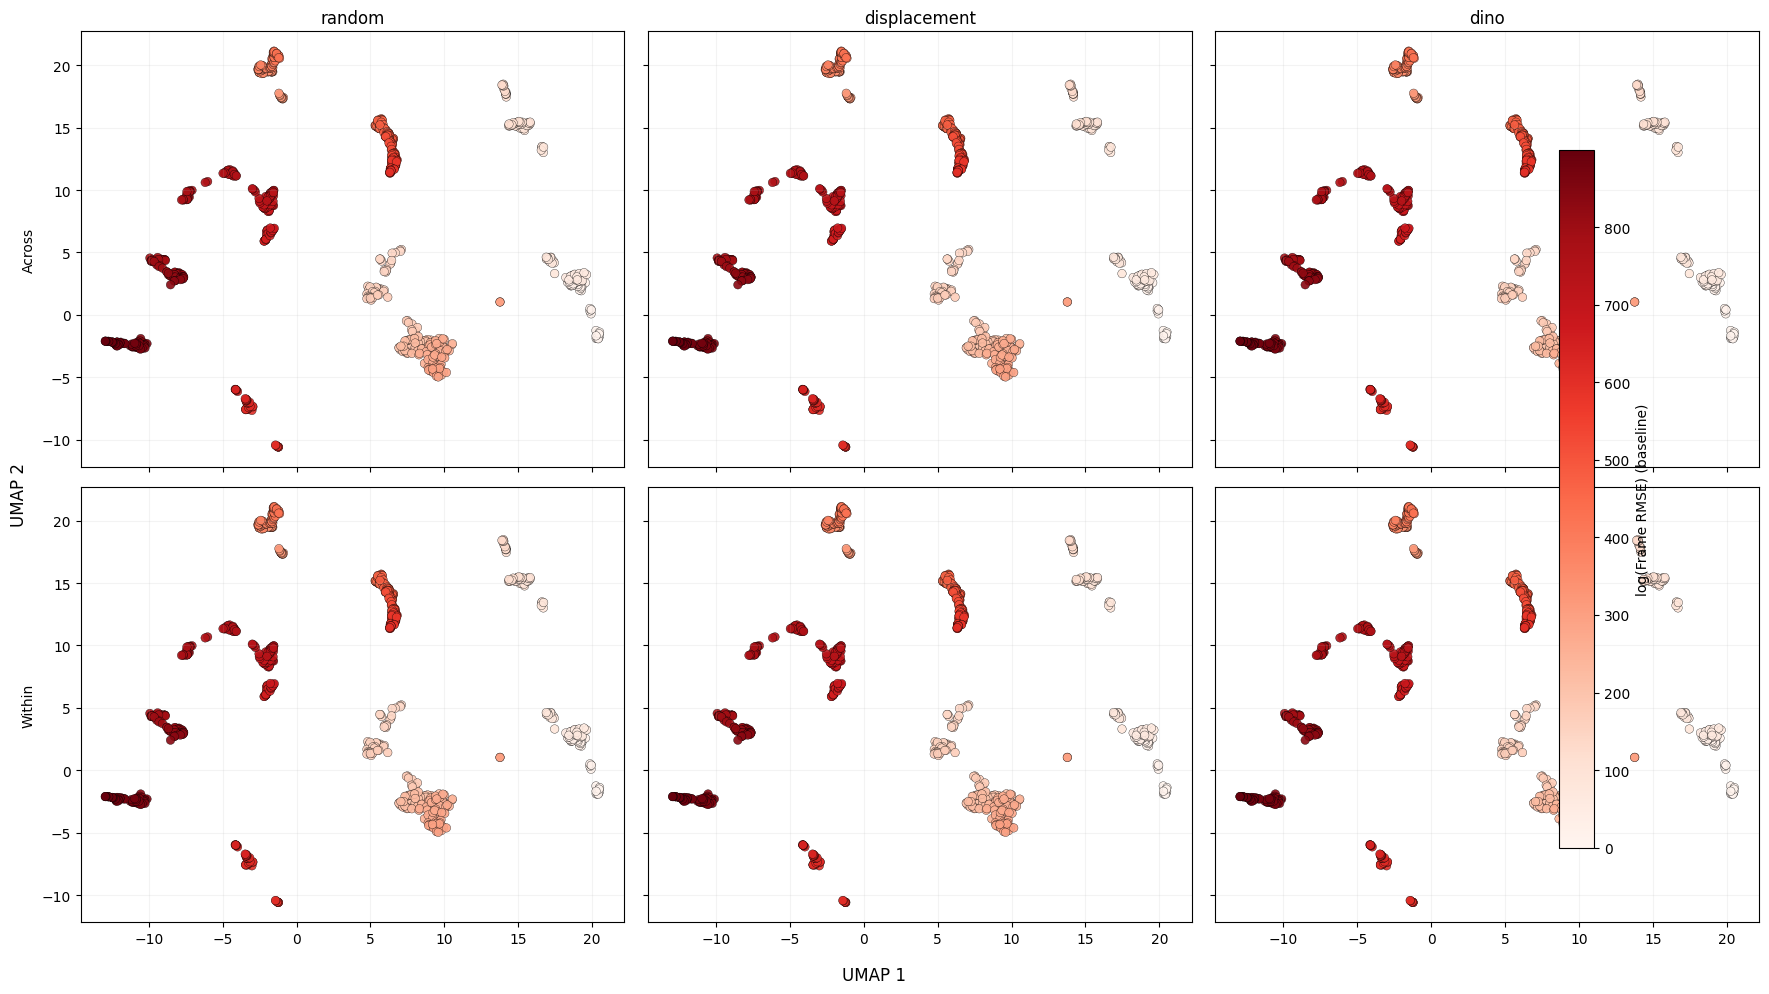

In [25]:
data_root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data"
)

dirs = [d for d in sorted(data_root.glob("DB_T*")) if d.is_dir()]

results, xlab, ylab = build_unified_embedding_results(
    dirs,
    comparison_df,
    point_errors_df_DB,
    error_view="baseline",
    camera="Cam1",
)


plot_unified_embedding_results(
    results,
    error_view="baseline",
    xlab=xlab,
    ylab=ylab,
)

In [26]:
point_errors_df_tulio = pd.read_csv(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data\evaluation_results\Tulio_within_across_point_errors_with_blobDetect_20260715_161004.csv")

Total images for unified embedding: 4078


Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main
c:\Users\Salle-Cineradio\Documents\miniconda\envs\DEEPLABCUT\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tulio_T10 pair= across test frames= 300
Tulio_T10 pair= within test frames= 300
Tulio_T5 pair= across test frames= 300
Tulio_T5 pair= within test frames= 300


C:\Users\Salle-Cineradio\AppData\Local\Temp\ipykernel_26720\3654609082.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


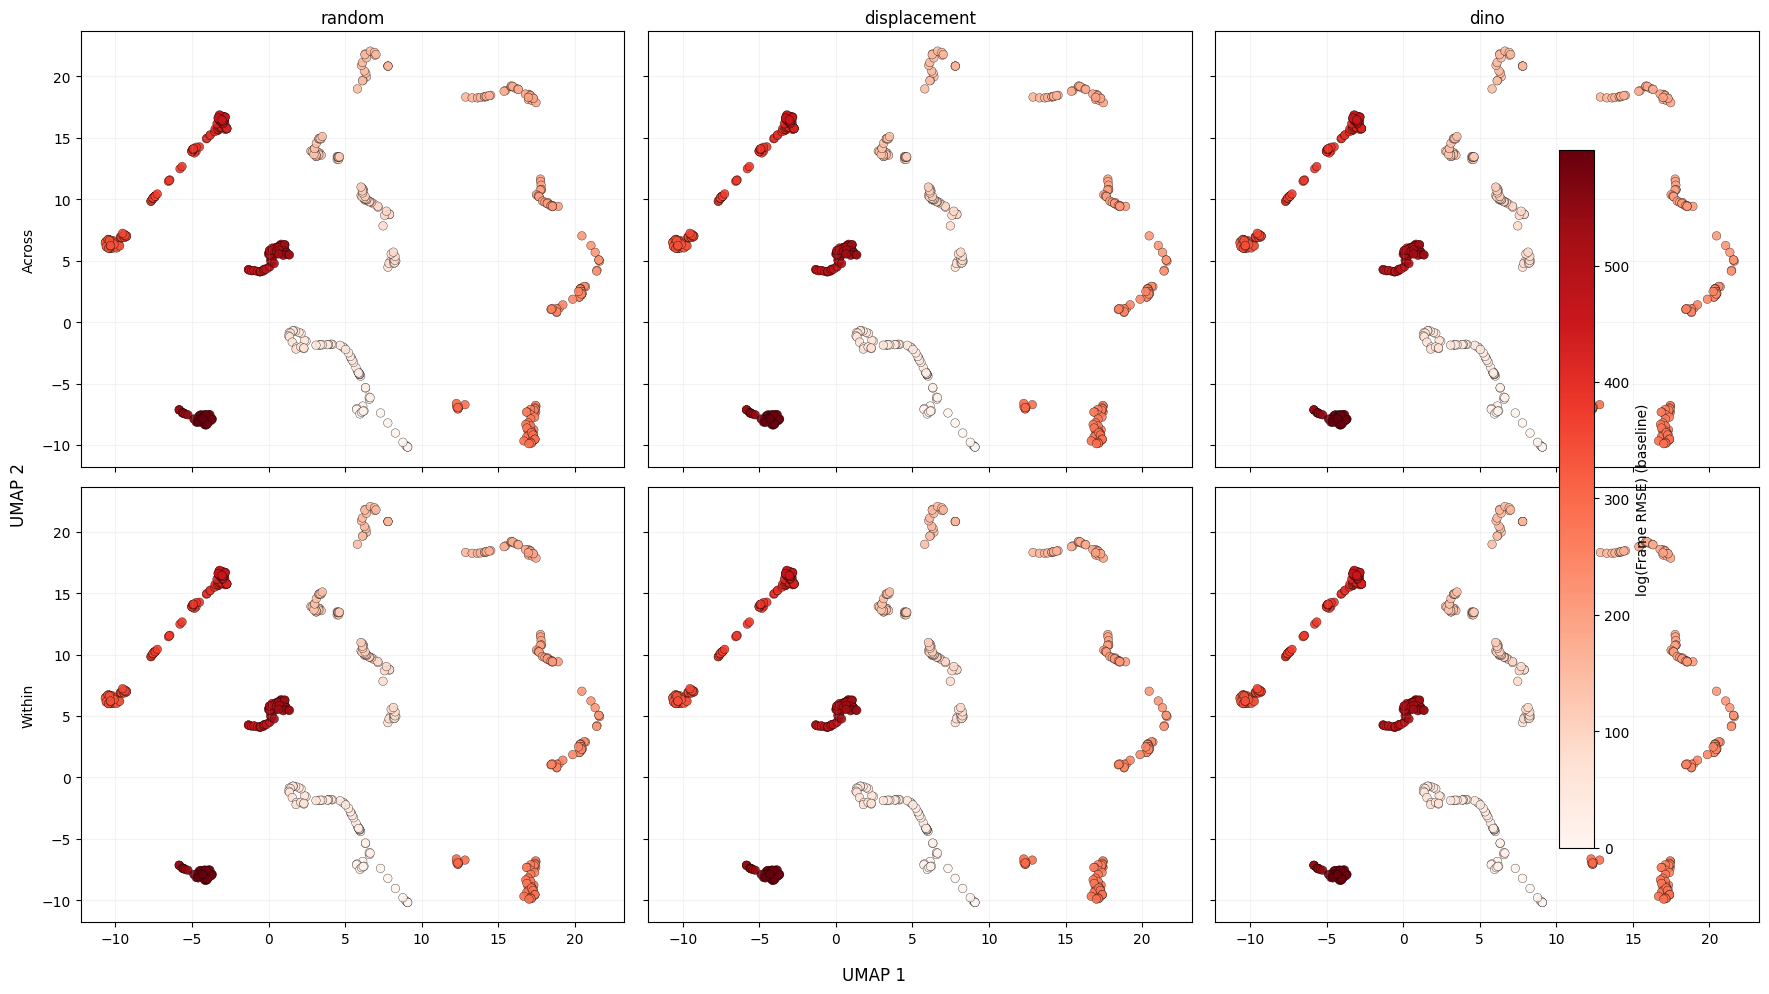

In [27]:
data_root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data"
)

dirs = [d for d in sorted(data_root.glob("Tulio_T*")) if d.is_dir()]

results, xlab, ylab = build_unified_embedding_results(
    dirs,
    comparison_df,
    point_errors_df_tulio,
    error_view="baseline",
    camera="Cam1",
)


plot_unified_embedding_results(
    results,
    error_view="baseline",
    xlab=xlab,
    ylab=ylab,
)

# ---------------------------------------------------------------------

### Ensemble Training

#### Needs adjustment to take entire set of data the we can accurately compare the others!

In [118]:
from pathlib import Path
from itertools import combinations
from shutil import copy2
import pandas as pd


root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data"
)

out_root = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\CombinedTrials"
)


def load_labels(csv_path):
    return pd.read_csv(csv_path)


for bird in sorted({p.name.split("_T")[0] for p in root.glob("*_T*")}):

    trials = sorted(root.glob(f"Tulio_T*"))

    # Every pair of trials
    for trial1, trial2 in combinations(trials, 2):

        t1 = trial1.name.split("_T")[1]
        t2 = trial2.name.split("_T")[1]

        out_dir = out_root / f"Tulio_T{t1}{t2}"

        cam1_out = out_dir / "completeSet" / "Cam1"
        cam2_out = out_dir / "completeSet" / "Cam2"

        cam1_out.mkdir(parents=True, exist_ok=True)
        cam2_out.mkdir(parents=True, exist_ok=True)

        labels = []

        image_number = 1
        if {t1, t2} == {"10", "5"}:
            continue

        # Process first trial then second trial
        for trial in (trial1, trial2):

            cam1_dir = trial / "completeSet" / "Cam1"
            cam2_dir = trial / "completeSet" / "Cam2"

            cam1_images = sorted(cam1_dir.glob("*"))
            cam2_images = sorted(cam2_dir.glob("*"))

            assert len(cam1_images) == len(cam2_images)

            df = load_labels(trial / "completeSet" / "LabeledBodyPartsCoordinates.csv")
            print(trial.name)
            print(len(cam1_images), len(cam2_images), len(df))
            for idx, (cam1, cam2) in enumerate(zip(cam1_images, cam2_images)):

                new_name = f"Image{image_number:05d}{cam1.suffix}"

                copy2(cam1, cam1_out / new_name)
                copy2(cam2, cam2_out / new_name)
                
                labels.append(df.iloc[idx])

                image_number += 1

        labels_df = pd.DataFrame(labels).reset_index(drop=True)

        labels_df.to_csv(
            out_dir / "completeSet" / "LabeledBodyPartsCoordinates.csv",
            index=False,
        )

        print(f"Created {out_dir.name}")

Tulio_T10
2849 2849 2849
Tulio_T105
4078 4078 4078
Created Tulio_T10105
Tulio_T10
2849 2849 2849
Tulio_T5
1229 1229 1229
Created Tulio_T105
Tulio_T10
2849 2849 2849
Tulio_T6
679 679 679
Created Tulio_T106
Tulio_T105
4078 4078 4078
Tulio_T5
1229 1229 1229
Created Tulio_T1055
Tulio_T105
4078 4078 4078
Tulio_T6
679 679 679
Created Tulio_T1056
Tulio_T5
1229 1229 1229
Tulio_T6
679 679 679
Created Tulio_T56
Tulio_T10
2849 2849 2849
Tulio_T105
4078 4078 4078
Created Tulio_T10105
Tulio_T10
2849 2849 2849
Tulio_T5
1229 1229 1229
Created Tulio_T105
Tulio_T10
2849 2849 2849
Tulio_T6
679 679 679
Created Tulio_T106
Tulio_T105
4078 4078 4078
Tulio_T5
1229 1229 1229
Created Tulio_T1055
Tulio_T105
4078 4078 4078
Tulio_T6
679 679 679
Created Tulio_T1056
Tulio_T5
1229 1229 1229
Tulio_T6
679 679 679
Created Tulio_T56
Tulio_T10
2849 2849 2849
Tulio_T105
4078 4078 4078
Created Tulio_T10105
Tulio_T10
2849 2849 2849
Tulio_T5
1229 1229 1229
Created Tulio_T105
Tulio_T10
2849 2849 2849
Tulio_T6
679 679 679
Crea

KeyboardInterrupt: 

In [105]:
root = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\Data_Working")

In [106]:
def collect_cam1_images(root: Path, bird: str):
    image_records = []

    for trial_dir in sorted(root.glob(f"{bird}_T*")):
        trial = trial_dir.name
        cam1 = trial_dir / "completeSet" / "Cam1"

        if not cam1.exists():
            continue
        for idx, img in enumerate(sorted(cam1.glob("*.jpg"))):

            image_records.append({
                "trial": trial,
                "path": img,
                "frame_idx": idx
            })

    return image_records

In [107]:
records = collect_cam1_images(root, "DB")

paths = [r["path"] for r in records]

selected = dsbuilder._select_dino_indices(paths, 800)

selected_records = [records[i] for i in selected]

Using cache found in C:\Users\Salle-Cineradio/.cache\torch\hub\facebookresearch_dinov2_main


In [108]:
def corresponding_cam2(cam1_path: Path) -> Path:
    cam2_name = cam1_path.stem.replace("Cam1_", "Cam2_", 1) + cam1_path.suffix
    cam2 = cam1_path.parent.parent / "Cam2" / cam2_name

    if not cam2.exists():
        raise FileNotFoundError(cam2)

    return cam2

In [109]:
from shutil import copy2

out_dir = Path(
    r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\DB_1517\CompleteSet"
)

cam1_out = out_dir / "Cam1"
cam2_out = out_dir / "Cam2"

cam1_out.mkdir(parents=True, exist_ok=True)
cam2_out.mkdir(parents=True, exist_ok=True)

for i, rec in enumerate(selected_records, start=1):

    cam1 = rec["path"]
    cam2 = corresponding_cam2(cam1)

    # Preserve the original extension (.jpg/.png)
    ext = cam1.suffix

    new_name = f"Image{i:03d}{ext}"   # Image001.jpg ... Image400.jpg

    copy2(cam1, cam1_out / new_name)
    copy2(cam2, cam2_out / new_name)

In [110]:
from collections import defaultdict

trial_to_indices = defaultdict(list)

for rec in selected_records:
    trial_to_indices[rec["trial"]].append(rec["frame_idx"])

In [111]:
import pandas as pd

dfs = pd.DataFrame()

for trial, indices in trial_to_indices.items():
    print(trial)
    print(len(indices))
    csv = (
        root
        / trial
        / "completeSet"
        / "LabeledBodyPartsCoordinates.csv"
    )

    df = pd.read_csv(csv)
    df_subset = df.iloc[indices]
    dfs = pd.concat([dfs, df_subset])
    
out_dir = Path(r"C:\Users\Salle-Cineradio\Documents\MachineLearning\BirdSongs-MNHN\Testing\DeepLabCutExperiments\DB_1517\CompleteSet\LabeledBodyPartsCoordinates.csv")
print(dfs)
dfs.to_csv(out_dir, index=False)

DB_T15
394
DB_T17
406
      Cranium_Left_Anterior_cam1_X  Cranium_Left_Anterior_cam1_Y  \
0                       374.051042                    177.387317   
4                       374.062160                    177.449801   
10                      373.869068                    177.531705   
14                      373.755754                    177.405124   
18                      373.583263                    177.339892   
...                            ...                           ...   
1554                    367.500000                    173.000000   
1556                    366.500000                    175.000000   
1557                    366.000000                    176.500000   
1558                    365.500000                    178.500000   
1559                    364.500000                    180.500000   

      Cranium_Left_Anterior_cam2_X  Cranium_Left_Anterior_cam2_Y  \
0                       254.926150                    192.048370   
4                       2